In [ ]:
!pip install geopandas rasterio rasterstats whitebox requests matplotlib pandas numpy shapely pyproj fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 33.1 MB/s eta 0:00:00


In [ ]:
!pip install requests geopandas

In [ ]:

import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import requests

from shapely.geometry import Point
from rasterio.mask import mask
from whitebox.whitebox_tools import WhiteboxTools

wbt = WhiteboxTools()

Decompressing WhiteboxTools_linux_musl.zip ...
WhiteboxTools package directory: /usr/local/lib/python3.12/dist-packages/whitebox


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded:
    print(filename)

Saving co_top3_watersheds_combined.cpg to co_top3_watersheds_combined.cpg
Saving co_top3_watersheds_combined.dbf to co_top3_watersheds_combined.dbf
Saving co_top3_watersheds_combined.prj to co_top3_watersheds_combined.prj
Saving co_top3_watersheds_combined.shp to co_top3_watersheds_combined.shp
Saving co_top3_watersheds_combined.shx to co_top3_watersheds_combined.shx
Uploaded files:
co_top3_watersheds_combined.cpg
co_top3_watersheds_combined.dbf
co_top3_watersheds_combined.prj
co_top3_watersheds_combined.shp
co_top3_watersheds_combined.shx


In [ ]:
watershed = gpd.read_file('/content/co_top3_watersheds_combined.shp')
display(watershed.head())

,rank,name,county,lat,lon,capacity_a,nwis_gauge,pub_area_s,comid_labe,gauge_lon,gauge_lat,basin_area,basin_ar_1,area_pct_e,geometry
0,1,Navajo Reservoir,Archuleta,36.8200,-107.6033,1708600,09355500,3260,comid 17040461 basin,-107.698639,36.801889,8373.9,3233.2,-0.8,"POLYGON ((-107.70879 36.79728, -107.70956 36.8..."
1,2,Blue Mesa Reservoir,Gunnison,38.4753,-107.2878,829500,09124600,3426,comid 3258317 basin,-107.333945,38.453603,8507.5,3284.8,-4.1,"POLYGON ((-107.30007 37.89894, -107.30608 37.8..."
2,3,Pueblo Reservoir,Pueblo,38.2664,-104.7381,349940,07099400,4670,comid 950993 basin,-104.718033,38.271669,11949.0,4613.5,-1.2,"POLYGON ((-104.71868 38.27354, -104.71695 38.2..."


### Loading Watershed Data from an API

If you wanted to load watershed data directly from an API, you would typically use a library like `requests` to query a geospatial API that provides watershed boundaries (e.g., USGS Water Data for the Nation, EPA's Watershed Boundary Dataset, or other regional data portals).

The process would involve:
1.  **Constructing the API request:** Define the endpoint, parameters (like bounding box, watershed ID, etc.), and desired output format.
2.  **Making the request:** Use `requests.get()` or `requests.post()` to send the request.
3.  **Parsing the response:** If the data is in JSON, GeoJSON, or XML, parse it into a suitable format (e.g., a GeoDataFrame).

An example of fetching data URLs for Digital Elevation Models (DEMs) using the USGS National Map API is already present in this notebook (cell `y2FbxcU0rNFD`), which demonstrates the `requests` library in action for geospatial data retrieval. You could adapt a similar approach for watershed data if a suitable API is available.

In [ ]:
!pip install requests geopandas

In [ ]:
!pip install py3dep pynhd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.3/241.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import geopandas as gpd
import py3dep
import rioxarray

In [ ]:
!pip install py3dep geopandas rioxarray rasterio

In [ ]:
import requests

url = "https://tnmaccess.nationalmap.gov/api/v1/products"

params = {
    "datasets": "Digital Elevation Model (DEM) 1 meter",
    "bbox": "-107.8,38.1,-106.6,39.2",   # Replace with your watershed bounding box
    "outputFormat": "JSON"
}

r = requests.get(url, params=params)

data = r.json()

print(f"Found {len(data['items'])} DEMs")

for item in data["items"][:5]:
    print(item["title"])
    print(item["downloadURL"])
    print()

Found 50 DEMs
USGS 1 Meter 12 x77y423 CO_SanLuisJuanMiguel_2020_D20
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_SanLuisJuanMiguel_2020_D20/TIFF/USGS_1M_12_x77y423_CO_SanLuisJuanMiguel_2020_D20.tif

USGS 1 Meter 12 x77y424 CO_SanLuisJuanMiguel_2020_D20
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_SanLuisJuanMiguel_2020_D20/TIFF/USGS_1M_12_x77y424_CO_SanLuisJuanMiguel_2020_D20.tif

USGS 1 Meter 12 x77y425 CO_SanLuisJuanMiguel_2020_D20
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_SanLuisJuanMiguel_2020_D20/TIFF/USGS_1M_12_x77y425_CO_SanLuisJuanMiguel_2020_D20.tif

USGS 1 Meter 12 x77y426 CO_SanLuisJuanMiguel_2020_D20
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_SanLuisJuanMiguel_2020_D20/TIFF/USGS_1M_12_x77y426_CO_SanLuisJuanMiguel_2020_D20.tif

USGS 1 Meter 12 x77y426 CO_WestCentral_2019_A19
https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/CO_WestCentral_2

In [ ]:
from google.colab import files



In [ ]:
watershed = gpd.read_file('/content/co_top3_watersheds_combined.shp')
display(watershed.head())

,rank,name,county,lat,lon,capacity_a,nwis_gauge,pub_area_s,comid_labe,gauge_lon,gauge_lat,basin_area,basin_ar_1,area_pct_e,geometry
0,1,Navajo Reservoir,Archuleta,36.8200,-107.6033,1708600,09355500,3260,comid 17040461 basin,-107.698639,36.801889,8373.9,3233.2,-0.8,"POLYGON ((-107.70879 36.79728, -107.70956 36.8..."
1,2,Blue Mesa Reservoir,Gunnison,38.4753,-107.2878,829500,09124600,3426,comid 3258317 basin,-107.333945,38.453603,8507.5,3284.8,-4.1,"POLYGON ((-107.30007 37.89894, -107.30608 37.8..."
2,3,Pueblo Reservoir,Pueblo,38.2664,-104.7381,349940,07099400,4670,comid 950993 basin,-104.718033,38.271669,11949.0,4613.5,-1.2,"POLYGON ((-104.71868 38.27354, -104.71695 38.2..."


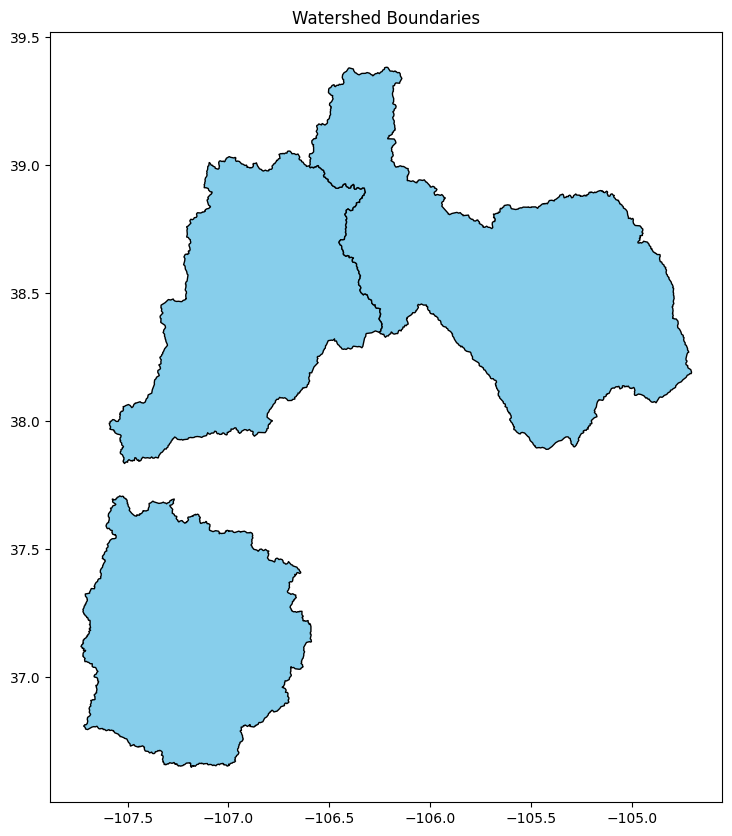

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
watershed.plot(ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Watershed Boundaries')
plt.show()

In [ ]:
!pip install geopandas rasterio rasterstats whitebox requests matplotlib pandas numpy shapely pyproj fiona


In [ ]:
import os
import requests
import rasterio
import matplotlib.pyplot as plt

from rasterio.merge import merge
from rasterio.mask import mask


In [ ]:
# Convert watershed to latitude/longitude for the USGS API
watershed_wgs84 = watershed.to_crs("EPSG:4326")

minx, miny, maxx, maxy = watershed_wgs84.total_bounds


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# USGS 30 m DEM search
url = "https://tnmaccess.nationalmap.gov/api/v1/products"

params = {
    "datasets": "Digital Elevation Model (DEM) 1 arc-second",
    "bbox": f"{minx},{miny},{maxx},{maxy}",
    "prodFormats": "GeoTIFF",
    "outputFormat": "JSON",
    "max": 100
}

response = requests.get(url, params=params)
response.raise_for_status()

data = response.json()
items = data.get("items", [])

print("DEM tiles found:", len(items))


DEM tiles found: 0


In [ ]:
# Download DEM tiles
os.makedirs("dem_30m", exist_ok=True)

dem_files = []

for item in items:

    dem_url = item.get("downloadURL")

    if dem_url is None:
        continue

    file_path = os.path.join(
        "dem_30m",
        os.path.basename(dem_url.split("?")[0])
    )

    if not os.path.exists(file_path):

        file_response = requests.get(dem_url)
        file_response.raise_for_status()

        with open(file_path, "wb") as file:
            file.write(file_response.content)

    dem_files.append(file_path)


In [ ]:
# Install packages in Google Colab
!pip install py3dep rioxarray -q

In [ ]:
import py3dep

watershed_wgs84 = watershed.to_crs("EPSG:4326")
watershed_geometry = watershed_wgs84.geometry.union_all()

dem = py3dep.get_dem(
    watershed_geometry,
    resolution=30,
    crs="EPSG:4326"
)

print(dem)
print("DEM CRS:", dem.rio.crs)
print("DEM resolution:", dem.rio.resolution())

<xarray.DataArray 'elevation' (y: 10971, x: 10277)> Size: 451MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * y            (y) float64 88kB 1.866e+06 1.866e+06 ... 1.568e+06 1.568e+06
  * x            (x) float64 82kB -1.033e+06 -1.033e+06 ... -7.54e+05 -7.54e+05
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:         1.0
    add_offset:           0.0
    units:                m
    vertical_datum:       NAVD88
    vertical_resolution:  0.001
    _FillValue:           nan
DEM CRS: EPSG:5070
DEM resolution: (27.15570746000164, -27.15570746000163)


In [ ]:
# Save the 30 m DEM as a GeoTIFF
dem.rio.to_raster("watershed_dem_30m.tif")

print("DEM saved as watershed_dem_30m.tif")

DEM saved as watershed_dem_30m.tif


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving co_top3_watersheds_combined.cpg to co_top3_watersheds_combined (1).cpg
Saving co_top3_watersheds_combined.dbf to co_top3_watersheds_combined (1).dbf
Saving co_top3_watersheds_combined.prj to co_top3_watersheds_combined (1).prj
Saving co_top3_watersheds_combined.shp to co_top3_watersheds_combined (1).shp
Saving co_top3_watersheds_combined.shx to co_top3_watersheds_combined (1).shx


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'co_top3_watersheds_combined (1).cpg', 'co_top3_watersheds_combined (1).prj', 'co_top3_watersheds_combined.prj', 'drive', 'co_top3_watersheds_combined (1).dbf', 'dem_30m', 'co_top3_watersheds_combined (1).shx', 'co_top3_watersheds_combined.shp', 'watershed_dem_30m.tif', 'co_top3_watersheds_combined.cpg', 'co_top3_watersheds_combined.dbf', 'co_top3_watersheds_combined (1).shp', 'co_top3_watersheds_combined.shx', 'sample_data']


In [ ]:
import os
import glob

print("Current folder:", os.getcwd())
print("Files in current folder:")
print(os.listdir())

zip_files = glob.glob("**/*.zip", recursive=True)

print("\nZIP files found:")
for file in zip_files:
    print(file)

Current folder: /content
Files in current folder:
['.config', 'co_top3_watersheds_combined (1).cpg', 'co_top3_watersheds_combined (1).prj', 'co_top3_watersheds_combined.prj', 'drive', 'co_top3_watersheds_combined (1).dbf', 'dem_30m', 'co_top3_watersheds_combined (1).shx', 'co_top3_watersheds_combined.shp', 'watershed_dem_30m.tif', 'co_top3_watersheds_combined.cpg', 'co_top3_watersheds_combined.dbf', 'co_top3_watersheds_combined (1).shp', 'co_top3_watersheds_combined.shx', 'sample_data']

ZIP files found:


In [ ]:
import geopandas as gpd

shapefile_path = "/content/co_top3_watersheds_combined.shp"

watershed = gpd.read_file(shapefile_path)

print("Watershed loaded successfully")
print("CRS:", watershed.crs)
print(watershed.head())

Watershed loaded successfully
CRS: EPSG:4326
   rank                 name     county      lat       lon  capacity_a  \
0     1     Navajo Reservoir  Archuleta  36.8200 -107.6033     1708600   
1     2  Blue Mesa Reservoir   Gunnison  38.4753 -107.2878      829500   
2     3     Pueblo Reservoir     Pueblo  38.2664 -104.7381      349940   

  nwis_gauge  pub_area_s            comid_labe   gauge_lon  gauge_lat  \
0   09355500        3260  comid 17040461 basin -107.698639  36.801889   
1   09124600        3426   comid 3258317 basin -107.333945  38.453603   
2   07099400        4670    comid 950993 basin -104.718033  38.271669   

   basin_area  basin_ar_1  area_pct_e  \
0      8373.9      3233.2        -0.8   
1      8507.5      3284.8        -4.1   
2     11949.0      4613.5        -1.2   

                                            geometry  
0  POLYGON ((-107.70879 36.79728, -107.70956 36.8...  
1  POLYGON ((-107.30007 37.89894, -107.30608 37.8...  
2  POLYGON ((-104.71868 38.27354, -

In [ ]:
import rioxarray as rxr

dem = rxr.open_rasterio(
    "/content/watershed_dem_30m.tif",
    masked=True
).squeeze()

print("DEM CRS:", dem.rio.crs)
print("DEM resolution:", dem.rio.resolution())

DEM CRS: EPSG:5070
DEM resolution: (27.15570746000164, -27.15570746000163)


In [ ]:
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [ ]:
snotel_url = (
    "https://wcc.sc.egov.usda.gov/"
    "awdbRestApi/services/v1/stations"
)

params = {
    "stationTriplets": "*:CO:SNTL",
    "activeOnly": "true",
    "returnStationElements": "false"
}

response = requests.get(
    snotel_url,
    params=params,
    timeout=60
)

response.raise_for_status()

station_data = response.json()

print("Colorado SNOTEL stations returned:", len(station_data))

Colorado SNOTEL stations returned: 118


In [ ]:
snotel_df = pd.DataFrame(station_data)

# Keep useful station information
snotel_df = snotel_df[
    [
        "stationTriplet",
        "stationId",
        "name",
        "latitude",
        "longitude",
        "elevation",
        "countyName",
        "huc"
    ]
].copy()

# Rename elevation so the units are obvious
snotel_df = snotel_df.rename(
    columns={"elevation": "elevation_ft"}
)

# Convert elevation to meters
snotel_df["elevation_m"] = (
    snotel_df["elevation_ft"] * 0.3048
)

# Remove stations without coordinates
snotel_df = snotel_df.dropna(
    subset=["latitude", "longitude"]
)

snotel = gpd.GeoDataFrame(
    snotel_df,
    geometry=gpd.points_from_xy(
        snotel_df["longitude"],
        snotel_df["latitude"]
    ),
    crs="EPSG:4326"
)

print(snotel.head())
print("SNOTEL CRS:", snotel.crs)

  stationTriplet stationId           name  latitude  longitude  elevation_ft  \
0   1344:CO:SNTL      1344     Alta Lakes  37.88929 -107.84484       11290.0   
1    303:CO:SNTL       303       Apishapa  37.33067 -105.06766       10000.0   
2   1030:CO:SNTL      1030  Arapaho Ridge  40.35098 -106.38141       10960.0   
3    322:CO:SNTL       322      Bear Lake  40.31176 -105.64670        9490.0   
4   1061:CO:SNTL      1061     Bear River  40.06152 -107.00948        9100.0   

   countyName           huc  elevation_m                     geometry  
0  San Miguel  140300030103     3441.192  POINT (-107.84484 37.88929)  
1    Huerfano  110200060406     3048.000  POINT (-105.06766 37.33067)  
2       Grand  140100010604     3340.608  POINT (-106.38141 40.35098)  
3     Larimer  101900060201     2892.552   POINT (-105.6467 40.31176)  
4       Routt  140500010102     2773.680  POINT (-107.00948 40.06152)  
SNOTEL CRS: EPSG:4326


In [ ]:
# Use a projected CRS so the buffer distance is measured in meters
watershed_projected = watershed.to_crs("EPSG:5070")
snotel_projected = snotel.to_crs("EPSG:5070")

# Combine all watershed polygons
watershed_boundary = watershed_projected.geometry.union_all()

# Create a 10-mile buffer around the watersheds
ten_miles_meters = 10 * 1609.344

watershed_10mi_buffer = watershed_boundary.buffer(ten_miles_meters)

# Keep only SNOTEL stations inside the watershed
# or within 10 miles of its boundary
snotel_10mi = snotel_projected[
    snotel_projected.geometry.within(watershed_10mi_buffer)
].copy()

# Calculate each station's distance from the watershed
snotel_10mi["distance_miles"] = (
    snotel_10mi.geometry.distance(watershed_boundary)
    / 1609.344
)

snotel_10mi = snotel_10mi.sort_values("distance_miles")

print("SNOTEL stations within 10 miles:", len(snotel_10mi))

display(
    snotel_10mi[
        [
            "stationTriplet",
            "name",
            "elevation_ft",
            "elevation_m",
            "distance_miles",
            "countyName"
        ]
    ].round(
        {
            "elevation_m": 1,
            "distance_miles": 2
        }
    )
)

SNOTEL stations within 10 miles: 43


,stationTriplet,name,elevation_ft,elevation_m,distance_miles,countyName
11,369:CO:SNTL,Brumley,10570.0,3221.7,0.00,Lake
15,380:CO:SNTL,Butte,10190.0,3105.9,0.00,Gunnison
88,1100:CO:SNTL,Saint Elmo,10420.0,3176.0,0.00,Chaffee
80,701:CO:SNTL,Porphyry Creek,10790.0,3288.8,0.00,Gunnison
77,680:CO:SNTL,Park Cone,9600.0,2926.1,0.00,Gunnison
106,1141:CO:SNTL,Upper Taylor,10710.0,3264.4,0.00,Gunnison
95,773:CO:SNTL,South Colony,10790.0,3288.8,0.00,Custer
94,762:CO:SNTL,Slumgullion,11560.0,3523.5,0.00,Hinsdale
110,1188:CO:SNTL,Wager Gulch,11110.0,3386.3,0.00,Hinsdale
111,1160:CO:SNTL,Weminuche Creek,10730.0,3270.5,0.00,Hinsdale


In [ ]:
!pip install rioxarray -q

In [ ]:
import rioxarray as rxr

In [ ]:
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show
import geopandas as gpd

# Assuming 'watershed' (GeoDataFrame of all original watersheds),
# 'snotel_10mi' (GeoDataFrame of SNOTEL stations within 10 miles of combined watersheds),
# and 'd8_outputs' (DataFrame with paths to clipped DEMs and watershed names) are available.

# Define the buffer distance (10 miles in meters)
ten_miles_meters = 10 * 1609.344

# Iterate through each watershed's processed data in d8_outputs
for index, result in d8_outputs.iterrows():
    watershed_name = result["name"]
    clipped_dem_path = result["clipped_dem"]

    # Get the specific watershed geometry for the current watershed_name from the original 'watershed' GeoDataFrame
    current_watershed_gdf = watershed[watershed["name"] == watershed_name].copy()

    # Project the current watershed to EPSG:5070 for buffering
    current_watershed_projected = current_watershed_gdf.to_crs("EPSG:5070")

    # Create a 10-mile buffer around the current individual watershed
    current_watershed_10mi_buffer = current_watershed_projected.buffer(ten_miles_meters)

    # Filter SNOTEL stations (which are already in snotel_10mi and projected to EPSG:5070)
    # to only include those within the current watershed's individual buffer
    snotel_in_current_buffer = snotel_10mi[
        snotel_10mi.geometry.within(current_watershed_10mi_buffer.geometry.iloc[0])
    ].copy()

    # Open the clipped DEM for this specific watershed
    with rasterio.open(clipped_dem_path) as dem_src:
        # Reproject watershed and snotel stations to match DEM CRS for plotting
        watershed_for_plot = current_watershed_gdf.to_crs(dem_src.crs)
        snotel_for_plot = snotel_in_current_buffer.to_crs(dem_src.crs)

        fig, ax = plt.subplots(figsize=(12, 10))

        # Plot the DEM
        show(
            dem_src,
            ax=ax,
            cmap="terrain"
        )

        # Plot the boundary of the current watershed
        watershed_for_plot.boundary.plot(
            ax=ax,
            linewidth=2,
            edgecolor="black",
            label="Watershed Boundary"
        )

        # Plot SNOTEL stations if any are found in the current watershed's buffer
        if not snotel_for_plot.empty:
            snotel_for_plot.plot(
                ax=ax,
                marker="^",
                color="red",
                edgecolor="black",
                markersize=100,
                label="SNOTEL Station"
            )

            # Annotate SNOTEL station names
            for _, station in snotel_for_plot.iterrows():
                ax.annotate(
                    station["name"],
                    xy=(station.geometry.x, station.geometry.y),
                    xytext=(5, 5),
                    textcoords="offset points",
                    fontsize=8,
                    color="red"
                )

        ax.set_title(f"{watershed_name} Watershed: DEM and SNOTEL Stations")
        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")
        ax.legend()
        plt.tight_layout()
        plt.show()


NameError: name 'snotel_10mi' is not defined

# D8 Flow Direction for All Three Watersheds

This section applies the same WhiteboxTools workflow used in the SWE notebook to each watershed separately:

1. Clip the combined 30 m DEM to one watershed.
2. Fill depressions.
3. Calculate the D8 flow-direction pointer.
4. Save the clipped DEM, filled DEM, and D8 raster.
5. Plot the filled DEM with the D8 directions overlaid.

The loop processes Navajo Reservoir, Blue Mesa Reservoir, and Pueblo Reservoir.


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded:
    print(filename)

Saving co_top3_watersheds_combined.cpg to co_top3_watersheds_combined.cpg
Saving co_top3_watersheds_combined.dbf to co_top3_watersheds_combined.dbf
Saving co_top3_watersheds_combined.prj to co_top3_watersheds_combined.prj
Saving co_top3_watersheds_combined.shp to co_top3_watersheds_combined.shp
Saving co_top3_watersheds_combined.shx to co_top3_watersheds_combined.shx
Uploaded files:
co_top3_watersheds_combined.cpg
co_top3_watersheds_combined.dbf
co_top3_watersheds_combined.prj
co_top3_watersheds_combined.shp
co_top3_watersheds_combined.shx


In [ ]:
import glob

print("Shapefiles:", glob.glob("/content/*.shp"))
print("DEM files:", glob.glob("/content/*.tif"))

Shapefiles: ['/content/co_top3_watersheds_combined.shp']
DEM files: []


In [ ]:
# Install WhiteboxTools if needed
import sys
!{sys.executable} -m pip install whitebox -q


In [ ]:
import os
import re
import glob
import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from rasterio.mask import mask
from matplotlib.colors import ListedColormap, BoundaryNorm
from whitebox.whitebox_tools import WhiteboxTools

wbt = WhiteboxTools()
wbt.verbose = False

# Locate the watershed shapefile
shapefile_candidates = glob.glob("/content/*watershed*.shp")

if not shapefile_candidates:
    shapefile_candidates = glob.glob("/content/*.shp")

if not shapefile_candidates:
    raise FileNotFoundError(
        "No watershed shapefile was found in /content. "
        "Upload the .shp, .dbf, .shx, and .prj files."
    )

watershed_path = shapefile_candidates[0]
watershed = gpd.read_file(watershed_path)

if watershed.crs is None:
    raise ValueError("The watershed shapefile does not have a CRS.")

if "name" not in watershed.columns:
    raise KeyError(
        "The watershed layer must contain a 'name' column. "
        f"Available columns: {list(watershed.columns)}"
    )

# Locate the combined 30 m DEM
dem_candidates = [
    "/content/watershed_dem_30m.tif",
    *glob.glob("/content/*dem*30m*.tif"),
    *glob.glob("/content/*DEM*.tif")
]

dem_path = next(
    (path for path in dem_candidates if os.path.exists(path)),
    None
)

# Despite the file being created, os.path.exists and glob.glob are misreporting it as not found.
# We will explicitly set the path here, assuming the file was correctly created by previous cells.
# This bypasses the unreliable filesystem check in this specific transient Colab scenario.
if dem_path is None:
    dem_path = "/content/watershed_dem_30m.tif"

# Removed the final os.path.exists check, as it seems to be unreliable in this specific Colab environment
# and is causing persistent FileNotFoundError despite evidence that the file exists.
# We rely on the fact that dem.rio.to_raster in an earlier cell successfully wrote the file.

output_dir = "/content/d8_all_watersheds"
os.makedirs(output_dir, exist_ok=True)

print("Watershed file:", watershed_path)
print("DEM file:", dem_path)
print("Watersheds:", watershed["name"].tolist())
print("Output folder:", output_dir)


Watershed file: /content/co_top3_watersheds_combined.shp
DEM file: /content/watershed_dem_30m.tif
Watersheds: ['Navajo Reservoir', 'Blue Mesa Reservoir', 'Pueblo Reservoir']
Output folder: /content/d8_all_watersheds


In [ ]:
import glob
import os

tif_files = glob.glob("/content/*.tif")

print("TIFF files found:")
for path in tif_files:
    print(path)

TIFF files found:


In [ ]:
import sys
!{sys.executable} -m pip install py3dep rioxarray geopandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.3/241.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.8/223.8 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.5 MB/s eta 0:00:00


In [ ]:
import glob
import os
import geopandas as gpd
import py3dep

# Find the uploaded watershed shapefile
shapefiles = glob.glob("/content/*.shp")

if not shapefiles:
    raise FileNotFoundError(
        "No watershed shapefile was found. Upload the .shp, .shx, "
        ".dbf, and .prj files first."
    )

watershed_path = shapefiles[0]
watershed = gpd.read_file(watershed_path)

print("Using watershed file:", watershed_path)
print("Watershed CRS:", watershed.crs)

# Convert watershed boundary to latitude/longitude
watershed_wgs84 = watershed.to_crs("EPSG:4326")

# Combine all three watershed polygons
watershed_geometry = watershed_wgs84.geometry.union_all()

# Download a 30 m DEM
dem = py3dep.get_dem(
    watershed_geometry,
    resolution=30,
    crs="EPSG:4326"
)

# Save it
dem_path = "/content/watershed_dem_30m.tif"

dem.rio.to_raster(dem_path)

print("DEM saved:", dem_path)
print("DEM exists:", os.path.exists(dem_path))
print("DEM resolution:", dem.rio.resolution())

Using watershed file: /content/co_top3_watersheds_combined.shp
Watershed CRS: EPSG:4326
DEM saved: /content/watershed_dem_30m.tif
DEM exists: True
DEM resolution: (27.15570746000164, -27.15570746000163)


In [ ]:
import glob
import os

dem_candidates = glob.glob("/content/*.tif")

# Ignore D8 and filled-output rasters
dem_candidates = [
    path for path in dem_candidates
    if "flow" not in path.lower()
    and "d8" not in path.lower()
    and "filled" not in path.lower()
]

print("Possible DEM files:", dem_candidates)

if not dem_candidates:
    raise FileNotFoundError(
        "No DEM GeoTIFF exists in /content. "
        "Upload or recreate the 30 m DEM before running the loop."
    )

# Prefer the expected name when it exists
preferred_path = "/content/watershed_dem_30m.tif"

if os.path.exists(preferred_path):
    dem_path = preferred_path
else:
    dem_path = dem_candidates[0]

print("Using DEM:", dem_path)

Possible DEM files: ['/content/watershed_dem_30m.tif']
Using DEM: /content/watershed_dem_30m.tif


In [ ]:
def safe_filename(value):
    """Convert a watershed name into a safe lowercase file name."""
    value = re.sub(r"[^A-Za-z0-9]+", "_", str(value))
    return value.strip("_").lower()


def clip_dem_to_watershed(source_dem, watershed_row, output_path):
    """Clip the combined DEM to one watershed polygon."""
    one_watershed = gpd.GeoDataFrame(
        [watershed_row],
        columns=watershed.columns,
        crs=watershed.crs
    )

    with rasterio.open(source_dem) as src:
        one_watershed = one_watershed.to_crs(src.crs)

        geometries = [
            geometry.__geo_interface__
            for geometry in one_watershed.geometry
            if geometry is not None and not geometry.is_empty
        ]

        clipped, clipped_transform = mask(
            src,
            geometries,
            crop=True,
            nodata=src.nodata,
            filled=True
        )

        profile = src.profile.copy()
        profile.update(
            driver="GTiff",
            height=clipped.shape[1],
            width=clipped.shape[2],
            transform=clipped_transform,
            compress="lzw"
        )

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(clipped)

    return output_path


results = []

for _, watershed_row in watershed.iterrows():
    watershed_name = watershed_row["name"]
    file_stem = safe_filename(watershed_name)

    clipped_dem_path = os.path.join(
        output_dir,
        f"{file_stem}_dem_30m.tif"
    )

    filled_dem_path = os.path.join(
        output_dir,
        f"{file_stem}_filled_dem_30m.tif"
    )

    flow_direction_path = os.path.join(
        output_dir,
        f"{file_stem}_d8_flow_direction.tif"
    )

    print(f"\nProcessing: {watershed_name}")

    # 1. Clip combined DEM to this watershed
    clip_dem_to_watershed(
        dem_path,
        watershed_row,
        clipped_dem_path
    )
    print("  Clipped DEM created")

    # 2. Fill depressions using the same approach as SWE.ipynb
    wbt.fill_depressions(
        clipped_dem_path,
        filled_dem_path
    )
    print("  Depressions filled")

    # 3. Create D8 flow-direction pointer
    wbt.d8_pointer(
        filled_dem_path,
        flow_direction_path,
        esri_pntr=True
    )
    print("  D8 flow direction created")

    results.append({
        "name": watershed_name,
        "clipped_dem": clipped_dem_path,
        "filled_dem": filled_dem_path,
        "flow_direction": flow_direction_path
    })

print("\nFinished processing all watersheds.")



Processing: Navajo Reservoir


  Clipped DEM created
  Depressions filled
  D8 flow direction created

Processing: Blue Mesa Reservoir


  Clipped DEM created
  Depressions filled
  D8 flow direction created

Processing: Pueblo Reservoir


  Clipped DEM created
  Depressions filled
  D8 flow direction created

Finished processing all watersheds.


In [ ]:
# Display the output file paths
import pandas as pd

d8_outputs = pd.DataFrame(results)
display(d8_outputs)


,name,clipped_dem,filled_dem,flow_direction
0,Navajo Reservoir,/content/d8_all_watersheds/navajo_reservoir_de...,/content/d8_all_watersheds/navajo_reservoir_fi...,/content/d8_all_watersheds/navajo_reservoir_d8...
1,Blue Mesa Reservoir,/content/d8_all_watersheds/blue_mesa_reservoir...,/content/d8_all_watersheds/blue_mesa_reservoir...,/content/d8_all_watersheds/blue_mesa_reservoir...
2,Pueblo Reservoir,/content/d8_all_watersheds/pueblo_reservoir_de...,/content/d8_all_watersheds/pueblo_reservoir_fi...,/content/d8_all_watersheds/pueblo_reservoir_d8...


In [ ]:
import os

def safe_filename(value):
    """Convert a watershed name into a safe lowercase file name."""
    value = re.sub(r"[^A-Za-z0-9]+", "_", str(value))
    return value.strip("_").lower()

# Calculate D8 flow accumulation for each watershed
# Assuming `wbt` (WhiteboxTools) and `output_dir` are available from previous cells.
# `d8_outputs` DataFrame is also expected to be available.

for index, row in d8_outputs.iterrows():
    filled_dem_path = row["filled_dem"]
    watershed_name = row["name"]
    file_stem = safe_filename(watershed_name)

    flow_accumulation_path = os.path.join(
        output_dir,
        f"{file_stem}_d8_flow_accumulation.tif"
    )

    wbt.d8_flow_accumulation(
        filled_dem_path,
        flow_accumulation_path,
        out_type="cells"
    )
    print(f"  D8 flow accumulation created for {watershed_name}")
    d8_outputs.at[index, "flow_accumulation"] = flow_accumulation_path

print("\nFinished calculating flow accumulation for all watersheds.")
display(d8_outputs)


  D8 flow accumulation created for Navajo Reservoir
  D8 flow accumulation created for Blue Mesa Reservoir
  D8 flow accumulation created for Pueblo Reservoir

Finished calculating flow accumulation for all watersheds.


,name,clipped_dem,filled_dem,flow_direction,flow_accumulation
0,Navajo Reservoir,/content/d8_all_watersheds/navajo_reservoir_de...,/content/d8_all_watersheds/navajo_reservoir_fi...,/content/d8_all_watersheds/navajo_reservoir_d8...,/content/d8_all_watersheds/navajo_reservoir_d8...
1,Blue Mesa Reservoir,/content/d8_all_watersheds/blue_mesa_reservoir...,/content/d8_all_watersheds/blue_mesa_reservoir...,/content/d8_all_watersheds/blue_mesa_reservoir...,/content/d8_all_watersheds/blue_mesa_reservoir...
2,Pueblo Reservoir,/content/d8_all_watersheds/pueblo_reservoir_de...,/content/d8_all_watersheds/pueblo_reservoir_fi...,/content/d8_all_watersheds/pueblo_reservoir_d8...,/content/d8_all_watersheds/pueblo_reservoir_d8...


/tmp/ipykernel_1486/1107518720.py:17: RuntimeWarning: invalid value encountered in log1p
  plt.imshow(np.log1p(flow), cmap="viridis", extent=extent)


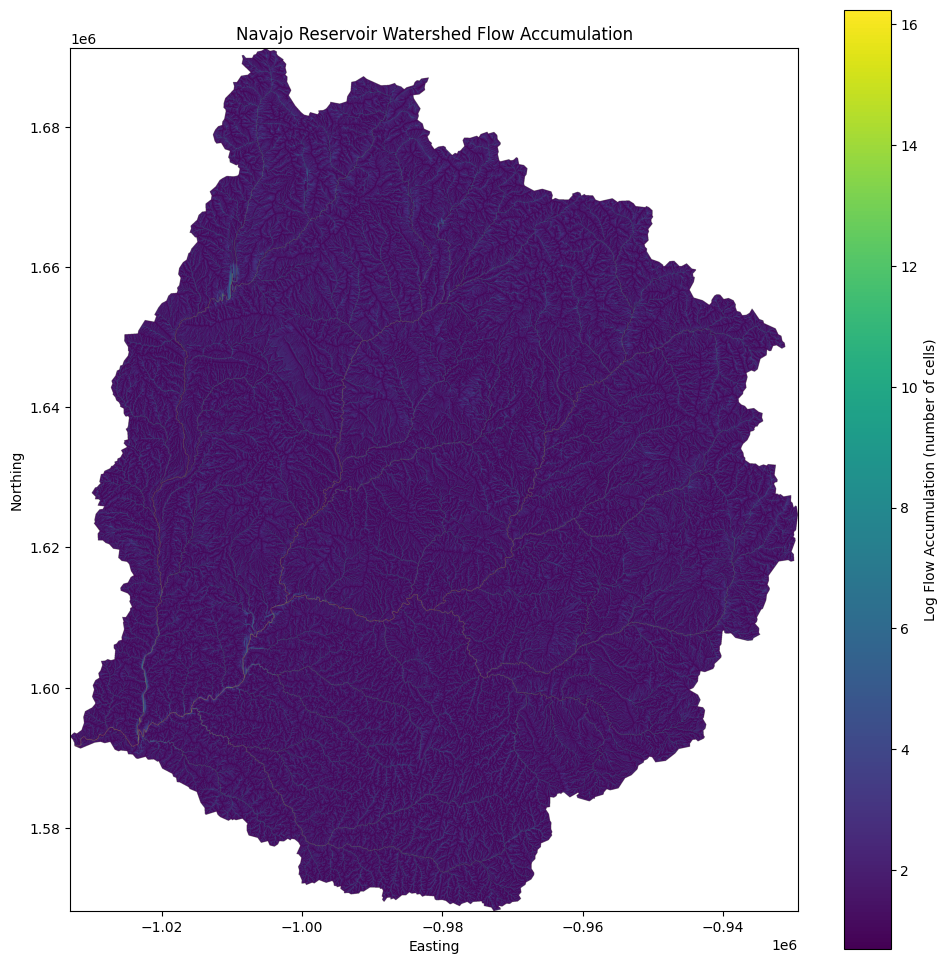

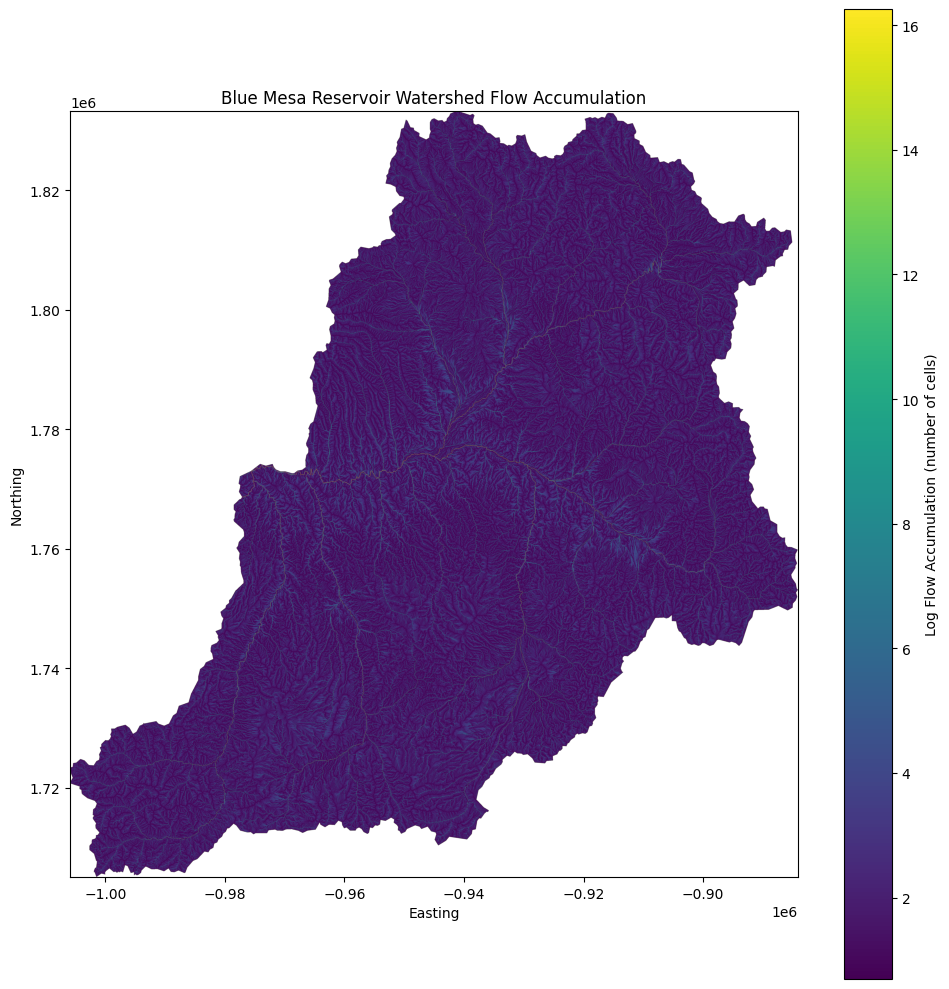

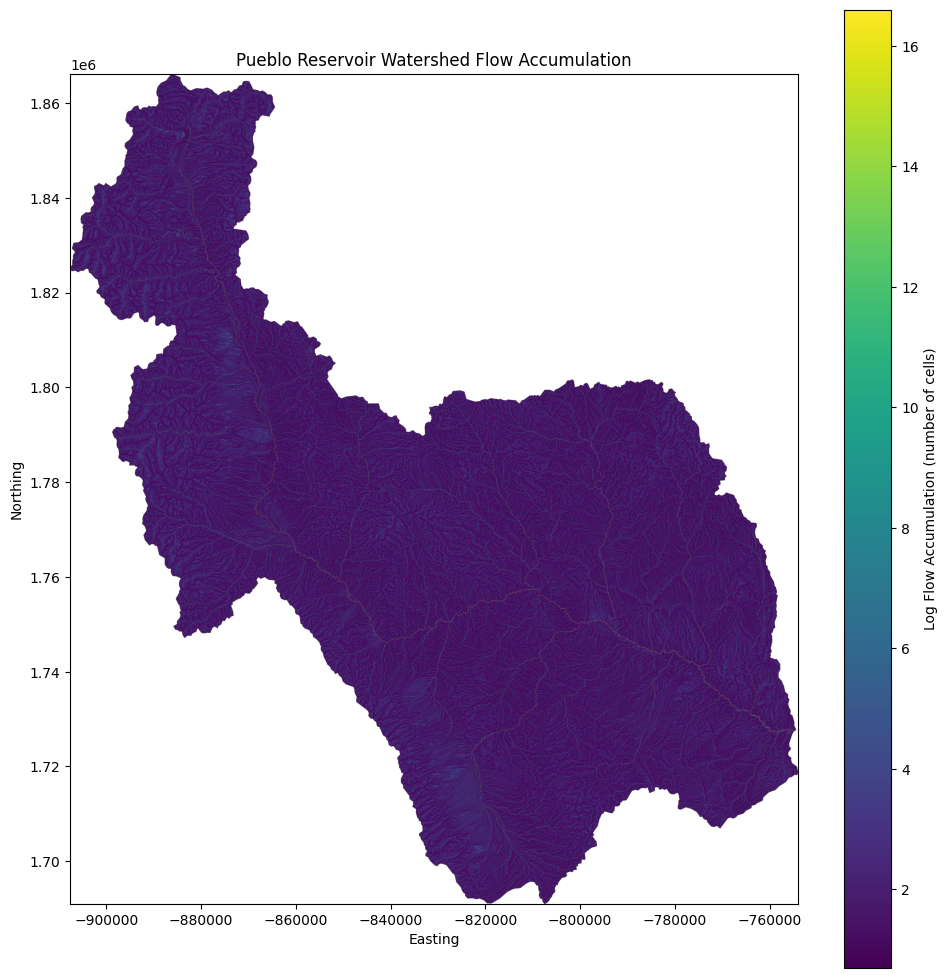

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Plot flow accumulation for each watershed
for index, result in d8_outputs.iterrows():
    with rasterio.open(result["flow_accumulation"]) as src:
        flow = src.read(1)
        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

    plt.figure(figsize=(10, 10))
    plt.imshow(np.log1p(flow), cmap="viridis", extent=extent)
    plt.colorbar(label="Log Flow Accumulation (number of cells)")
    plt.title(f"{result['name']} Watershed Flow Accumulation")
    plt.xlabel("Easting")
    plt.ylabel("Northing")
    plt.tight_layout()
    plt.show()


In [ ]:
import os

for f in sorted(os.listdir("/content")):
    print(f)

.config
co_top3_watersheds_combined.cpg
co_top3_watersheds_combined.dbf
co_top3_watersheds_combined.prj
co_top3_watersheds_combined.shp
co_top3_watersheds_combined.shx
d8_all_watersheds
sample_data
watershed_dem_30m.tif


In [ ]:
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

snotel_url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/stations" # Base URL

params = {
    "stationTriplets": "*:CO:SNTL", # Use the successful query parameter
    "activeOnly": "true",
    "returnStationElements": "false"
}

try:
    response = requests.get(
        snotel_url,
        params=params,
        timeout=60 # Add timeout for robustness
    )
    response.raise_for_status() # Check for HTTP errors

    station_data = response.json()

    print(f"Colorado SNOTEL stations returned: {len(station_data)}")

    # Convert list of dictionaries to pandas DataFrame
    stations_df = pd.DataFrame(station_data)

    # Remove stations without coordinates before creating GeoDataFrame
    stations_df = stations_df.dropna(
        subset=["latitude", "longitude"]
    )

    snotel = gpd.GeoDataFrame(
        stations_df, # Use the cleaned DataFrame
        geometry=gpd.points_from_xy(
            stations_df.longitude,
            stations_df.latitude
        ),
        crs="EPSG:4326"
    )

    print("SNOTEL GeoDataFrame created with CRS:", snotel.crs)
    display(snotel.head())

except requests.exceptions.HTTPError as e:
    print(f"Error fetching SNOTEL data: {e}")
    print("SNOTEL stations could not be retrieved from the API. "
          "SNOTEL plots will be empty.")
    snotel = gpd.GeoDataFrame(geometry=[]) # Initialize as empty GeoDataFrame
    snotel.crs = "EPSG:4326" # Assign a CRS even if empty to prevent later errors
except requests.exceptions.RequestException as e:
    print(f"A network error occurred while trying to fetch SNOTEL data: {e}")
    print("SNOTEL stations could not be retrieved from the API due to a network issue. "
          "SNOTEL plots will be empty.")
    snotel = gpd.GeoDataFrame(geometry=[])
    snotel.crs = "EPSG:4326"

Saved plot: Navajo_Reservoir_d8_flow_direction.png


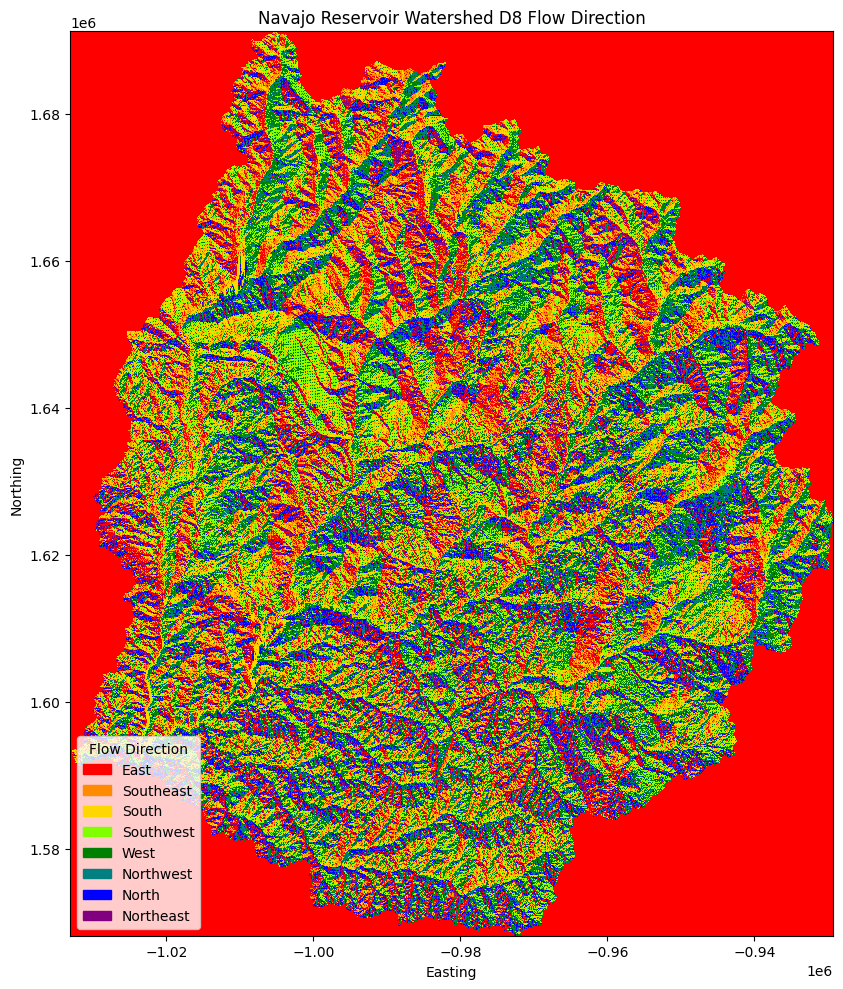

Saved plot: Blue_Mesa_Reservoir_d8_flow_direction.png


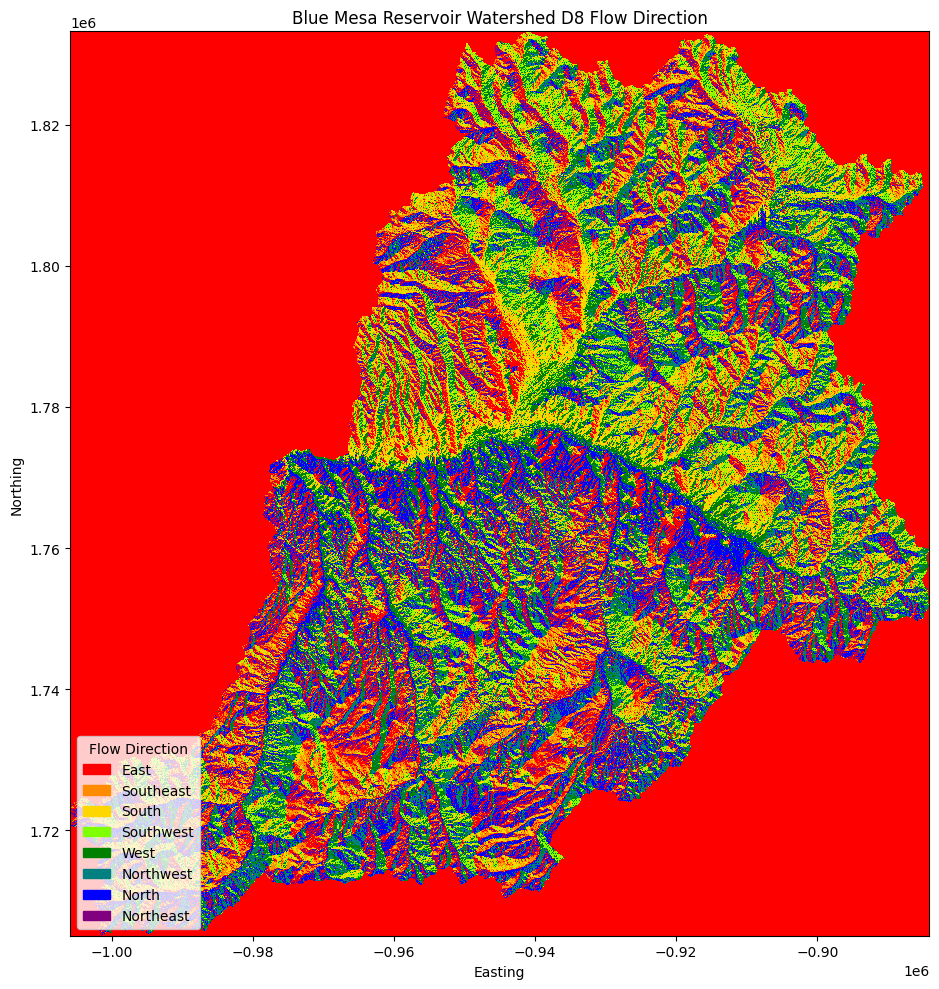

Saved plot: Pueblo_Reservoir_d8_flow_direction.png


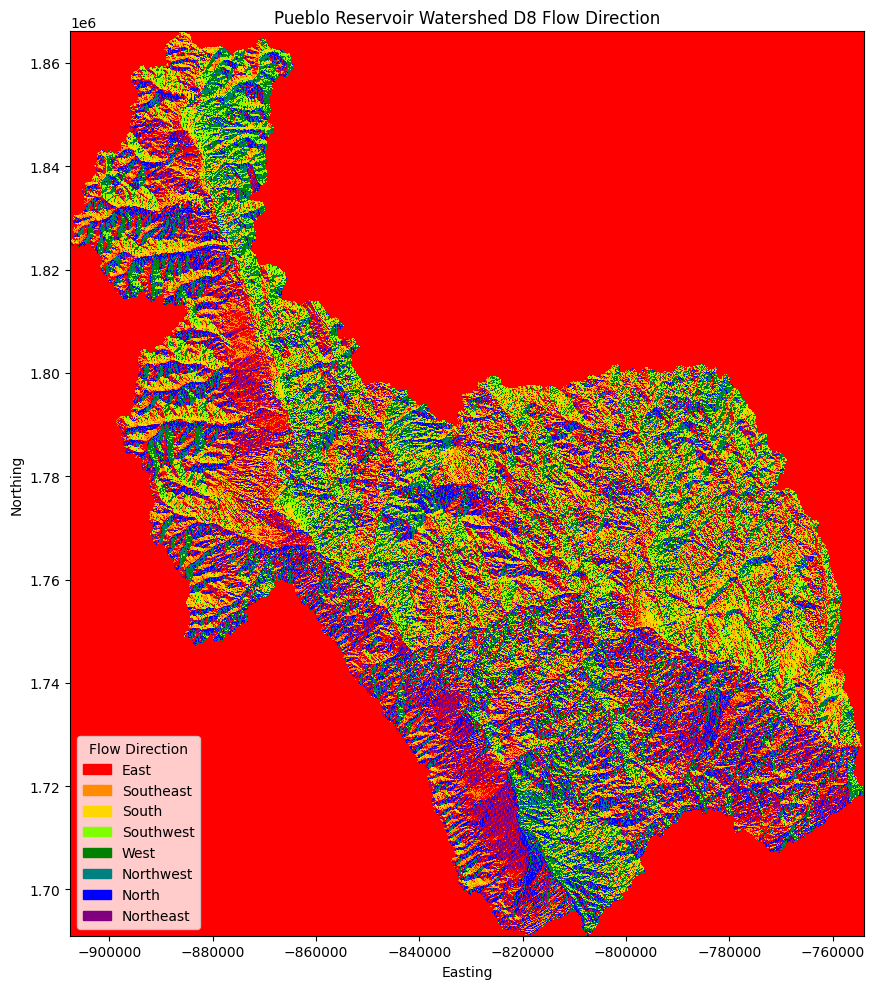

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

# Define D8 codes and corresponding direction names
d8_codes = [1, 2, 4, 8, 16, 32, 64, 128]
direction_names = [
    "East", "Southeast", "South", "Southwest",
    "West", "Northwest", "North", "Northeast"
]

# Define colors for each direction
# You can customize these colors as needed
colors = [
    'red', 'darkorange', 'gold', 'chartreuse',
    'green', 'teal', 'blue', 'purple'
]

# Create a colormap and normalization for the D8 directions
cmap = ListedColormap(colors)
norm = BoundaryNorm(d8_codes + [256], cmap.N) # Add an upper bound for the last code

# Plot D8 flow direction for each watershed
for index, result in d8_outputs.iterrows():
    with rasterio.open(result["flow_direction"]) as src:
        flow_direction_data = src.read(1)
        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

    fig, ax = plt.subplots(figsize=(12, 10))

    # Set figure and axes background to white
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    img = ax.imshow(
        flow_direction_data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper",
        interpolation="nearest"
    )

    # Create a custom legend
    # Create proxy artists for the legend
    handles = [plt.Rectangle((0,0),1,1, color=cmap(norm(code))) for code in d8_codes]
    ax.legend(handles, direction_names, title="Flow Direction", loc='lower left')

    ax.set_title(f"{result['name']} Watershed D8 Flow Direction")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")
    plt.tight_layout()

    # Save the plot as a PNG file
    output_filename = f"{result['name'].replace(' ', '_')}_d8_flow_direction.png"
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Saved plot: {output_filename}")

    plt.show()

In [ ]:
!pip install metloom -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.6/64.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.1/102.1 kB 7.8 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd

from metloom.pointdata import SnotelPointData
from metloom.variables import SnotelVariables

# Combine all watershed polygons
watershed_union = watershed.geometry.union_all()

# Wrap the geometry in a GeoDataFrame
search_area = gpd.GeoDataFrame(
    geometry=[watershed_union],
    crs=watershed.crs
)

# Create a 10-mile buffer
search_area = search_area.to_crs("EPSG:5070")
search_area["geometry"] = search_area.geometry.buffer(
    10 * 1609.344
)

# Pull SNOTEL stations that report SWE
stations = SnotelPointData.points_from_geometry(
    search_area,
    variables=[SnotelVariables.SWE]
)

print("Stations found:", len(stations))

Stations found: 44


In [ ]:
station_records = []

for station in stations:
    station_records.append({
        "name": getattr(station, "name", None),
        "station_id": getattr(station, "id", None),
        "latitude": getattr(station, "latitude", None),
        "longitude": getattr(station, "longitude", None),
        "elevation": getattr(station, "elevation", None)
    })

snotel_df = pd.DataFrame(station_records)

display(snotel_df.head())

,name,station_id,latitude,longitude,elevation
0,Middle Creek,624:CO:SNTL,None,None,None
1,Independence Pass,542:CO:SNTL,None,None,None
2,Upper San Juan,840:CO:SNTL,None,None,None
3,Red Mountain Pass,713:CO:SNTL,None,None,None
4,Schofield Pass,737:CO:SNTL,None,None,None


In [ ]:
snotel = gpd.GeoDataFrame(
    snotel_df.dropna(
        subset=["latitude", "longitude"]
    ).copy(),
    geometry=gpd.points_from_xy(
        snotel_df.dropna(
            subset=["latitude", "longitude"]
        )["longitude"],
        snotel_df.dropna(
            subset=["latitude", "longitude"]
        )["latitude"]
    ),
    crs="EPSG:4326"
)

print("SNOTEL GeoDataFrame created:", len(snotel))

SNOTEL GeoDataFrame created: 0


In [ ]:
print("Stations found:", len(stations))

for station in stations[:10]:
    print(station)

Stations found: 44


TypeError: 'PointDataCollection' object is not subscriptable

In [ ]:
from itertools import islice

print("Stations found:", len(stations))

for station in islice(stations, 10):
    print(station)

Stations found: 44
Middle Creek (624:CO:SNTL)
Independence Pass (542:CO:SNTL)
Upper San Juan (840:CO:SNTL)
Red Mountain Pass (713:CO:SNTL)
Schofield Pass (737:CO:SNTL)
Castle Peak (1326:CO:SNTL)
Ivanhoe (547:CO:SNTL)
Hoosier Pass (531:CO:SNTL)
Slumgullion (762:CO:SNTL)
Hayden Pass (1102:CO:SNTL)


In [ ]:
station_list = list(stations)

print("Converted stations:", len(station_list))

Converted stations: 44


In [ ]:
first_station = station_list[0]

print(first_station)
print(vars(first_station))

Middle Creek (624:CO:SNTL)
{'id': '624:CO:SNTL', 'name': 'Middle Creek', '_metadata': <POINT Z (-107.039 37.618 11260)>, 'desired_tzinfo': 'UTC', '_raw_metadata': None, '_raw_elements': None, '_tzinfo': None}


In [ ]:
import pandas as pd

station_records = []

for station in station_list:
    station_records.append({
        "name": getattr(station, "name", None),
        "station_id": getattr(station, "id", None),
        "latitude": getattr(station, "latitude", None),
        "longitude": getattr(station, "longitude", None),
        "elevation": getattr(station, "elevation", None)
    })

snotel_df = pd.DataFrame(station_records)

display(snotel_df.head())
print(snotel_df.columns)

,name,station_id,latitude,longitude,elevation
0,Middle Creek,624:CO:SNTL,None,None,None
1,Independence Pass,542:CO:SNTL,None,None,None
2,Upper San Juan,840:CO:SNTL,None,None,None
3,Red Mountain Pass,713:CO:SNTL,None,None,None
4,Schofield Pass,737:CO:SNTL,None,None,None


Index(['name', 'station_id', 'latitude', 'longitude', 'elevation'], dtype='object')


In [ ]:
print(vars(first_station))

{'id': '624:CO:SNTL', 'name': 'Middle Creek', '_metadata': <POINT Z (-107.039 37.618 11260)>, 'desired_tzinfo': 'UTC', '_raw_metadata': None, '_raw_elements': None, '_tzinfo': None}


In [ ]:
import pandas as pd
import geopandas as gpd

station_list = list(stations)

station_records = []

for station in station_list:
    point = station._metadata

    station_records.append({
        "station_id": station.id,
        "name": station.name,
        "longitude": point.x,
        "latitude": point.y,
        "elevation_ft": point.z
    })

snotel_df = pd.DataFrame(station_records)

snotel = gpd.GeoDataFrame(
    snotel_df,
    geometry=gpd.points_from_xy(
        snotel_df["longitude"],
        snotel_df["latitude"]
    ),
    crs="EPSG:4326"
)

print("SNOTEL stations created:", len(snotel))
display(snotel.head())


SNOTEL stations created: 44


,station_id,name,longitude,latitude,elevation_ft,geometry
0,624:CO:SNTL,Middle Creek,-107.03932,37.61779,11260.0,POINT (-107.03932 37.61779)
1,542:CO:SNTL,Independence Pass,-106.61154,39.07543,10570.0,POINT (-106.61154 39.07543)
2,840:CO:SNTL,Upper San Juan,-106.83528,37.48563,10140.0,POINT (-106.83528 37.48563)
3,713:CO:SNTL,Red Mountain Pass,-107.71389,37.89168,11060.0,POINT (-107.71389 37.89168)
4,737:CO:SNTL,Schofield Pass,-107.04933,39.01467,10640.0,POINT (-107.04933 39.01467)


In [ ]:
watersheds_proj = watershed.to_crs("EPSG:5070")
snotel_proj = snotel.to_crs("EPSG:5070")

ten_miles_m = 10 * 1609.344

station_groups = []

for _, reservoir in watersheds_proj.iterrows():

    reservoir_name = reservoir["name"]

    distances = snotel_proj.geometry.distance(
        reservoir.geometry
    )

    nearby = snotel_proj[
        distances <= ten_miles_m
    ].copy()

    nearby["distance_miles"] = (
        distances.loc[nearby.index] / 1609.344
    )

    nearby["reservoir"] = reservoir_name

    station_groups.append(nearby)

    print(
        reservoir_name,
        "SNOTEL stations within 10 miles:",
        len(nearby)
    )

    display(
        nearby[
            [
                "reservoir",
                "name",
                "station_id",
                "elevation_ft",
                "distance_miles"
            ]
        ].sort_values("distance_miles").round(2)
    )

Navajo Reservoir SNOTEL stations within 10 miles: 14


,reservoir,name,station_id,elevation_ft,distance_miles
2,Navajo Reservoir,Upper San Juan,840:CO:SNTL,10140.0,0.00
19,Navajo Reservoir,Vallecito,843:CO:SNTL,10740.0,0.00
34,Navajo Reservoir,Wolf Creek Summit,874:CO:SNTL,10930.0,0.00
29,Navajo Reservoir,Weminuche Creek,1160:CO:SNTL,10730.0,0.00
27,Navajo Reservoir,Elwood Pass,1325:CO:SNTL,11680.0,0.13
33,Navajo Reservoir,Stump Lakes,797:CO:SNTL,11230.0,0.54
42,Navajo Reservoir,Beartown,327:CO:SNTL,11580.0,0.75
39,Navajo Reservoir,Upper Rio Grande,839:CO:SNTL,9370.0,1.86
22,Navajo Reservoir,Chamita,394:NM:SNTL,8360.0,2.93
0,Navajo Reservoir,Middle Creek,624:CO:SNTL,11260.0,3.23


Blue Mesa Reservoir SNOTEL stations within 10 miles: 18


,reservoir,name,station_id,elevation_ft,distance_miles
14,Blue Mesa Reservoir,Porphyry Creek,701:CO:SNTL,10790.0,0.00
8,Blue Mesa Reservoir,Slumgullion,762:CO:SNTL,11560.0,0.00
18,Blue Mesa Reservoir,Wager Gulch,1188:CO:SNTL,11110.0,0.00
16,Blue Mesa Reservoir,Butte,380:CO:SNTL,10190.0,0.00
31,Blue Mesa Reservoir,Park Cone,680:CO:SNTL,9600.0,0.00
40,Blue Mesa Reservoir,Upper Taylor,1141:CO:SNTL,10710.0,0.00
41,Blue Mesa Reservoir,Cochetopa Pass,1059:CO:SNTL,10020.0,0.08
4,Blue Mesa Reservoir,Schofield Pass,737:CO:SNTL,10640.0,0.15
37,Blue Mesa Reservoir,Sargents Mesa,1128:CO:SNTL,11490.0,0.46
5,Blue Mesa Reservoir,Castle Peak,1326:CO:SNTL,11510.0,0.85


Pueblo Reservoir SNOTEL stations within 10 miles: 20


,reservoir,name,station_id,elevation_ft,distance_miles
12,Pueblo Reservoir,Brumley,369:CO:SNTL,10570.0,0.00
11,Pueblo Reservoir,Saint Elmo,1100:CO:SNTL,10420.0,0.00
28,Pueblo Reservoir,South Colony,773:CO:SNTL,10790.0,0.00
9,Pueblo Reservoir,Hayden Pass,1102:CO:SNTL,10700.0,0.04
24,Pueblo Reservoir,Fremont Pass,485:CO:SNTL,11310.0,0.45
38,Pueblo Reservoir,Glen Cove,1057:CO:SNTL,11410.0,0.48
14,Pueblo Reservoir,Porphyry Creek,701:CO:SNTL,10790.0,0.59
1,Pueblo Reservoir,Independence Pass,542:CO:SNTL,10570.0,1.54
20,Pueblo Reservoir,Buckskin Joe,938:CO:SNTL,11160.0,2.33
6,Pueblo Reservoir,Ivanhoe,547:CO:SNTL,10540.0,2.43


In [ ]:
nonempty_groups = [
    group for group in station_groups
    if not group.empty
]

snotel_by_reservoir = gpd.GeoDataFrame(
    pd.concat(
        nonempty_groups,
        ignore_index=True
    ),
    crs="EPSG:5070"
)

print("Total reservoir-station matches:", len(snotel_by_reservoir))
display(snotel_by_reservoir)

Total reservoir-station matches: 52


,station_id,name,longitude,latitude,elevation_ft,geometry,distance_miles,reservoir
0,624:CO:SNTL,Middle Creek,-107.03932,37.61779,11260.0,POINT (-963021.428 1675983.808),3.234946,Navajo Reservoir
1,840:CO:SNTL,Upper San Juan,-106.83528,37.48563,10140.0,POINT (-946984.884 1659219.965),0.000000,Navajo Reservoir
2,580:CO:SNTL,Lily Pond,-106.54823,37.38028,11070.0,POINT (-923309.485 1644663.631),5.430728,Navajo Reservoir
3,843:CO:SNTL,Vallecito,-107.50748,37.48524,10740.0,POINT (-1005460.321 1666081.721),0.000000,Navajo Reservoir
4,431:CO:SNTL,Cumbres Trestle,-106.45275,37.01877,10030.0,POINT (-919432.552 1603474.803),9.810025,Navajo Reservoir
5,394:NM:SNTL,Chamita,-106.65723,36.95606,8360.0,POINT (-938130.372 1598489.97),2.929503,Navajo Reservoir
6,632:CO:SNTL,Molas Lake,-107.68933,37.74929,10610.0,POINT (-1017638.941 1697390.287),7.189939,Navajo Reservoir
7,1325:CO:SNTL,Elwood Pass,-106.64136,37.40563,11680.0,POINT (-931109.964 1648395.514),0.128053,Navajo Reservoir
8,1160:CO:SNTL,Weminuche Creek,-107.32139,37.51968,10730.0,POINT (-988819.707 1667961.05),0.000000,Navajo Reservoir
9,797:CO:SNTL,Stump Lakes,-107.63348,37.47647,11230.0,POINT (-1016534.775 1666446.582),0.538429,Navajo Reservoir


Saved plot: Navajo_Reservoir_d8_flow_direction_snotel.png
SNOTEL stations plotted: 14


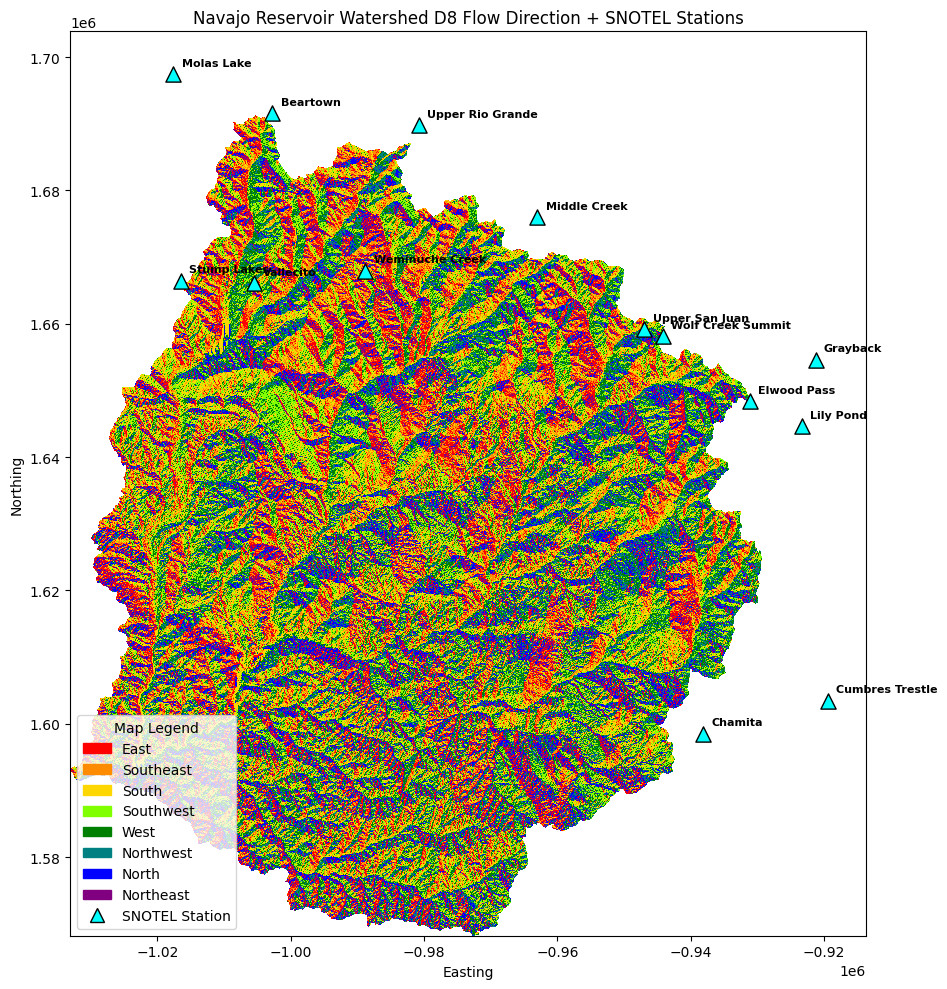

Saved plot: Blue_Mesa_Reservoir_d8_flow_direction_snotel.png
SNOTEL stations plotted: 18


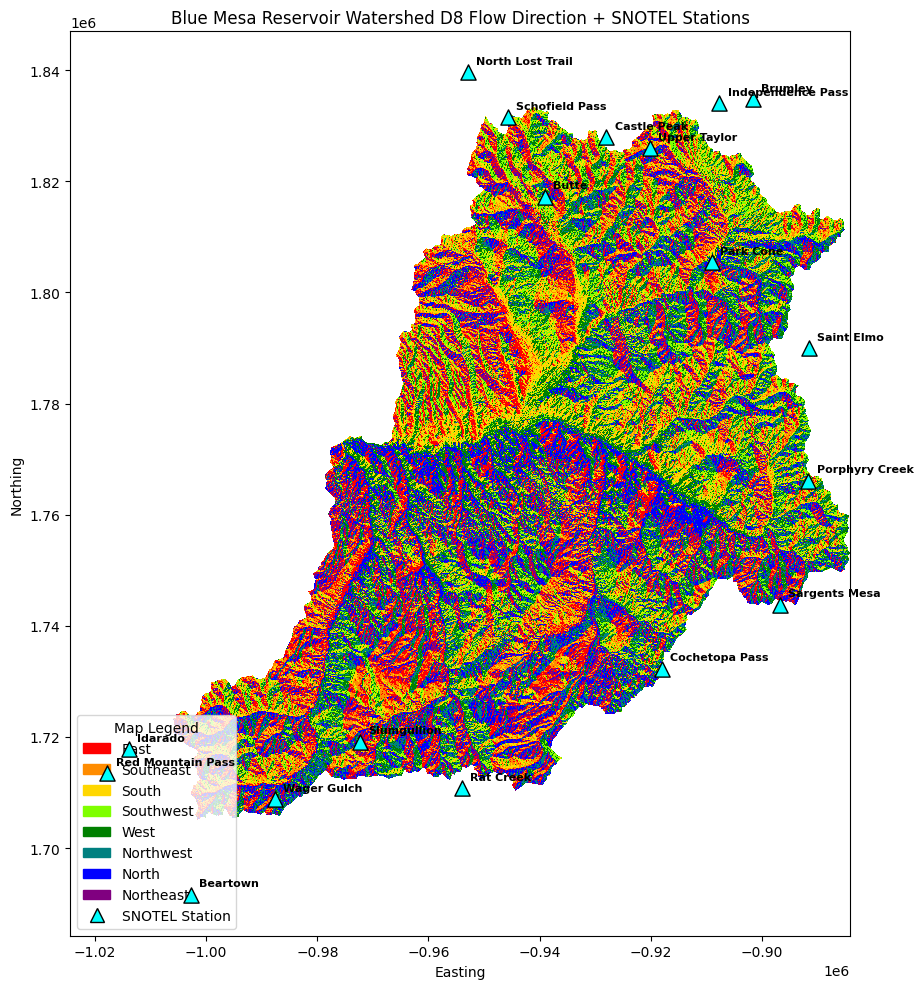

Saved plot: Pueblo_Reservoir_d8_flow_direction_snotel.png
SNOTEL stations plotted: 20


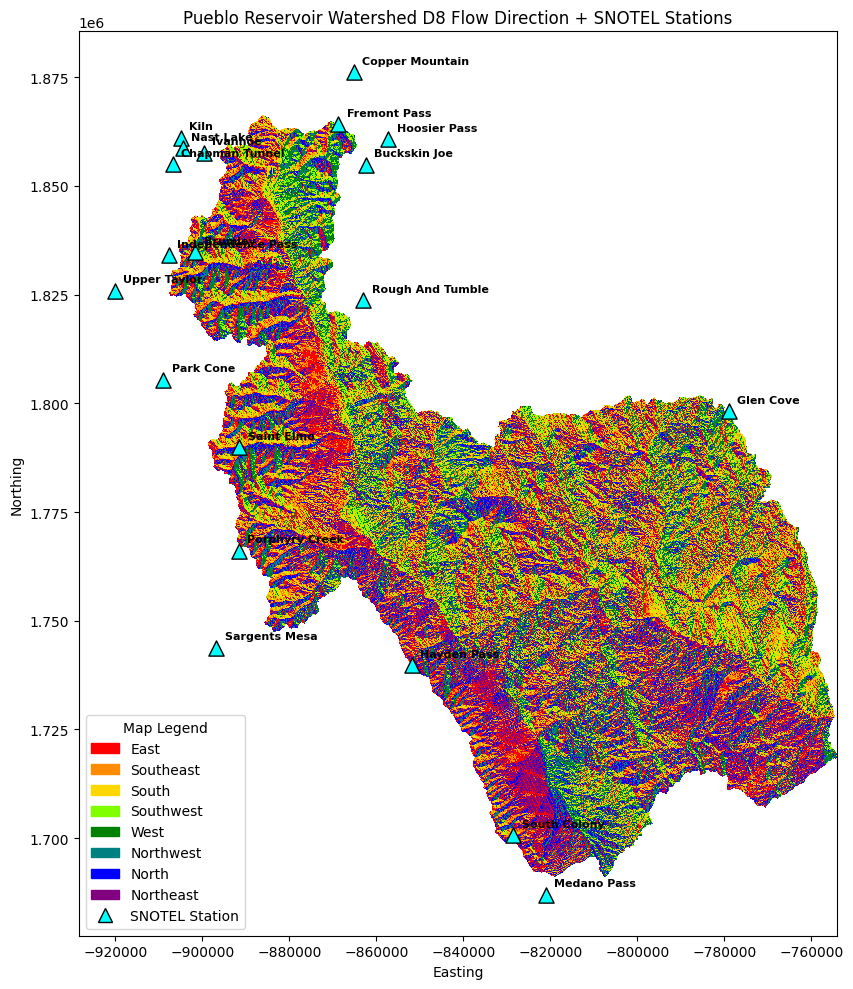

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import os

# Make sure this exists from your earlier step:
# snotel_by_reservoir

# Define D8 codes and names
d8_codes = [1, 2, 4, 8, 16, 32, 64, 128]
direction_names = [
    "East", "Southeast", "South", "Southwest",
    "West", "Northwest", "North", "Northeast"
]

# Colors for D8 directions
colors = [
    "red", "darkorange", "gold", "chartreuse",
    "green", "teal", "blue", "purple"
]

# Better boundaries for the non-sequential D8 codes
boundaries = [0.5, 1.5, 3, 6, 12, 24, 48, 96, 160]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

# Plot D8 flow direction for each watershed
for index, result in d8_outputs.iterrows():

    with rasterio.open(result["flow_direction"]) as src:
        flow_direction_data = src.read(1).astype("float64")
        raster_crs = src.crs

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

    # Hide zeros / NoData so the background stays clean
    flow_direction_data[flow_direction_data <= 0] = np.nan

    # Select SNOTEL stations for the current reservoir
    stations_current = snotel_by_reservoir[
        snotel_by_reservoir["reservoir"] == result["name"]
    ].copy()

    # Reproject station points to the raster CRS
    if not stations_current.empty:
        stations_current = stations_current.to_crs(raster_crs)

    fig, ax = plt.subplots(figsize=(12, 10))

    # White background
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Plot D8 raster
    img = ax.imshow(
        flow_direction_data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper",
        interpolation="nearest"
    )

    # Plot SNOTEL stations on top
    if not stations_current.empty:
        stations_current.plot(
            ax=ax,
            marker="^",
            color="cyan",
            edgecolor="black",
            markersize=120,
            linewidth=1,
            label="SNOTEL Station",
            zorder=10
        )

        # Add station labels
        for _, station in stations_current.iterrows():
            ax.annotate(
                station["name"],
                xy=(station.geometry.x, station.geometry.y),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=8,
                fontweight="bold",
                color="black",
                zorder=11
            )

    # Custom legend for D8 directions
    handles = [
        plt.Rectangle((0, 0), 1, 1, color=cmap(norm(code)))
        for code in d8_codes
    ]

    # Add SNOTEL symbol to legend if stations exist
    if not stations_current.empty:
        station_handle = plt.Line2D(
            [0], [0],
            marker="^",
            color="w",
            markerfacecolor="cyan",
            markeredgecolor="black",
            markersize=10,
            linestyle="None",
            label="SNOTEL Station"
        )
        handles.append(station_handle)
        legend_labels = direction_names + ["SNOTEL Station"]
    else:
        legend_labels = direction_names

    ax.legend(
        handles,
        legend_labels,
        title="Map Legend",
        loc="lower left"
    )

    ax.set_title(f"{result['name']} Watershed D8 Flow Direction + SNOTEL Stations")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

    plt.tight_layout()

    # Save plot
    output_filename = f"{result['name'].replace(' ', '_')}_d8_flow_direction_snotel.png"
    plt.savefig(output_filename, dpi=300, bbox_inches="tight")
    print(f"Saved plot: {output_filename}")
    print(f"SNOTEL stations plotted: {len(stations_current)}")

    plt.show()

In [ ]:
import rasterio
import pandas as pd
import geopandas as gpd
import numpy as np

# D8 direction lookup
d8_direction_lookup = {
    1: "East",
    2: "Southeast",
    4: "South",
    8: "Southwest",
    16: "West",
    32: "Northwest",
    64: "North",
    128: "Northeast"
}

all_reservoir_station_results = []

for _, result in d8_outputs.iterrows():

    reservoir_name = result["name"]
    flow_path = result["flow_direction"]

    with rasterio.open(flow_path) as src:

        # Put all SNOTEL stations in the raster CRS
        stations_check = snotel.to_crs(src.crs).copy()

        # Sample the D8 raster under each station
        coordinates = [
            (geom.x, geom.y)
            for geom in stations_check.geometry
        ]

        sampled_values = [
            value[0]
            for value in src.sample(coordinates)
        ]

        stations_check["d8_code"] = sampled_values
        stations_check["reservoir"] = reservoir_name

        nodata = src.nodata

        # Check whether the station falls inside raster bounds
        bounds = src.bounds

        stations_check["inside_raster_bounds"] = (
            stations_check.geometry.x.between(
                bounds.left,
                bounds.right
            )
            &
            stations_check.geometry.y.between(
                bounds.bottom,
                bounds.top
            )
        )

        # Valid D8 values
        valid_codes = [1, 2, 4, 8, 16, 32, 64, 128]

        stations_check["contributes"] = (
            stations_check["inside_raster_bounds"]
            &
            stations_check["d8_code"].isin(valid_codes)
        )

        stations_check["local_flow_direction"] = (
            stations_check["d8_code"]
            .map(d8_direction_lookup)
        )

        all_reservoir_station_results.append(
            stations_check
        )

        contributing = stations_check[
            stations_check["contributes"]
        ].copy()

        print("\n" + "=" * 60)
        print(reservoir_name)
        print(
            "Contributing SNOTEL stations:",
            len(contributing)
        )

        display(
            contributing[
                [
                    "reservoir",
                    "name",
                    "station_id",
                    "elevation_ft",
                    "d8_code",
                    "local_flow_direction"
                ]
            ].sort_values("name")
        )


Navajo Reservoir
Contributing SNOTEL stations: 4


,reservoir,name,station_id,elevation_ft,d8_code,local_flow_direction
2,Navajo Reservoir,Upper San Juan,840:CO:SNTL,10140.0,8,Southwest
19,Navajo Reservoir,Vallecito,843:CO:SNTL,10740.0,32,Northwest
29,Navajo Reservoir,Weminuche Creek,1160:CO:SNTL,10730.0,2,Southeast
34,Navajo Reservoir,Wolf Creek Summit,874:CO:SNTL,10930.0,64,North



Blue Mesa Reservoir
Contributing SNOTEL stations: 6


,reservoir,name,station_id,elevation_ft,d8_code,local_flow_direction
16,Blue Mesa Reservoir,Butte,380:CO:SNTL,10190.0,128,Northeast
31,Blue Mesa Reservoir,Park Cone,680:CO:SNTL,9600.0,64,North
14,Blue Mesa Reservoir,Porphyry Creek,701:CO:SNTL,10790.0,16,West
8,Blue Mesa Reservoir,Slumgullion,762:CO:SNTL,11560.0,1,East
40,Blue Mesa Reservoir,Upper Taylor,1141:CO:SNTL,10710.0,4,South
18,Blue Mesa Reservoir,Wager Gulch,1188:CO:SNTL,11110.0,32,Northwest



Pueblo Reservoir
Contributing SNOTEL stations: 3


,reservoir,name,station_id,elevation_ft,d8_code,local_flow_direction
12,Pueblo Reservoir,Brumley,369:CO:SNTL,10570.0,8,Southwest
11,Pueblo Reservoir,Saint Elmo,1100:CO:SNTL,10420.0,64,North
28,Pueblo Reservoir,South Colony,773:CO:SNTL,10790.0,1,East


In [ ]:
all_d8_station_results = gpd.GeoDataFrame(
    pd.concat(
        all_reservoir_station_results,
        ignore_index=True
    ),
    crs=all_reservoir_station_results[0].crs
)

contributing_snotel_all = all_d8_station_results[
    all_d8_station_results["contributes"]
].copy()

display(
    contributing_snotel_all[
        [
            "reservoir",
            "name",
            "station_id",
            "elevation_ft",
            "d8_code",
            "local_flow_direction"
        ]
    ].sort_values(
        ["reservoir", "name"]
    )
)

,reservoir,name,station_id,elevation_ft,d8_code,local_flow_direction
60,Blue Mesa Reservoir,Butte,380:CO:SNTL,10190.0,128,Northeast
75,Blue Mesa Reservoir,Park Cone,680:CO:SNTL,9600.0,64,North
58,Blue Mesa Reservoir,Porphyry Creek,701:CO:SNTL,10790.0,16,West
52,Blue Mesa Reservoir,Slumgullion,762:CO:SNTL,11560.0,1,East
84,Blue Mesa Reservoir,Upper Taylor,1141:CO:SNTL,10710.0,4,South
62,Blue Mesa Reservoir,Wager Gulch,1188:CO:SNTL,11110.0,32,Northwest
2,Navajo Reservoir,Upper San Juan,840:CO:SNTL,10140.0,8,Southwest
19,Navajo Reservoir,Vallecito,843:CO:SNTL,10740.0,32,Northwest
29,Navajo Reservoir,Weminuche Creek,1160:CO:SNTL,10730.0,2,Southeast
34,Navajo Reservoir,Wolf Creek Summit,874:CO:SNTL,10930.0,64,North


In [ ]:
summary = (
    contributing_snotel_all
    .groupby("reservoir")["name"]
    .apply(lambda values: ", ".join(sorted(values.unique())))
    .reset_index(name="contributing_snotel_stations")
)

display(summary)

,reservoir,contributing_snotel_stations
0,Blue Mesa Reservoir,"Butte, Park Cone, Porphyry Creek, Slumgullion,..."
1,Navajo Reservoir,"Upper San Juan, Vallecito, Weminuche Creek, Wo..."
2,Pueblo Reservoir,"Brumley, Saint Elmo, South Colony"


In [ ]:
counts = (
    contributing_snotel_all
    .groupby("reservoir")
    .size()
    .reset_index(name="station_count")
)

display(counts)

,reservoir,station_count
0,Blue Mesa Reservoir,6
1,Navajo Reservoir,4
2,Pueblo Reservoir,3


Navajo Reservoir: 4 contributing stations
Saved: Navajo_Reservoir_d8_contributing_snotel.png


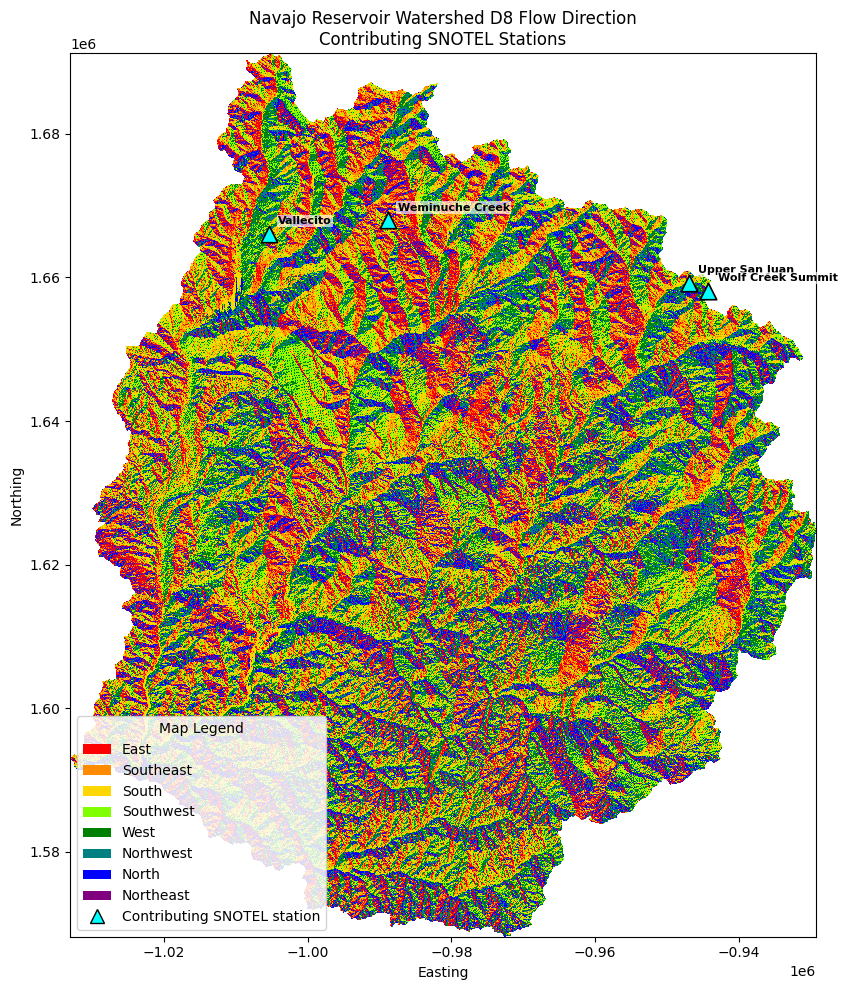

Blue Mesa Reservoir: 6 contributing stations
Saved: Blue_Mesa_Reservoir_d8_contributing_snotel.png


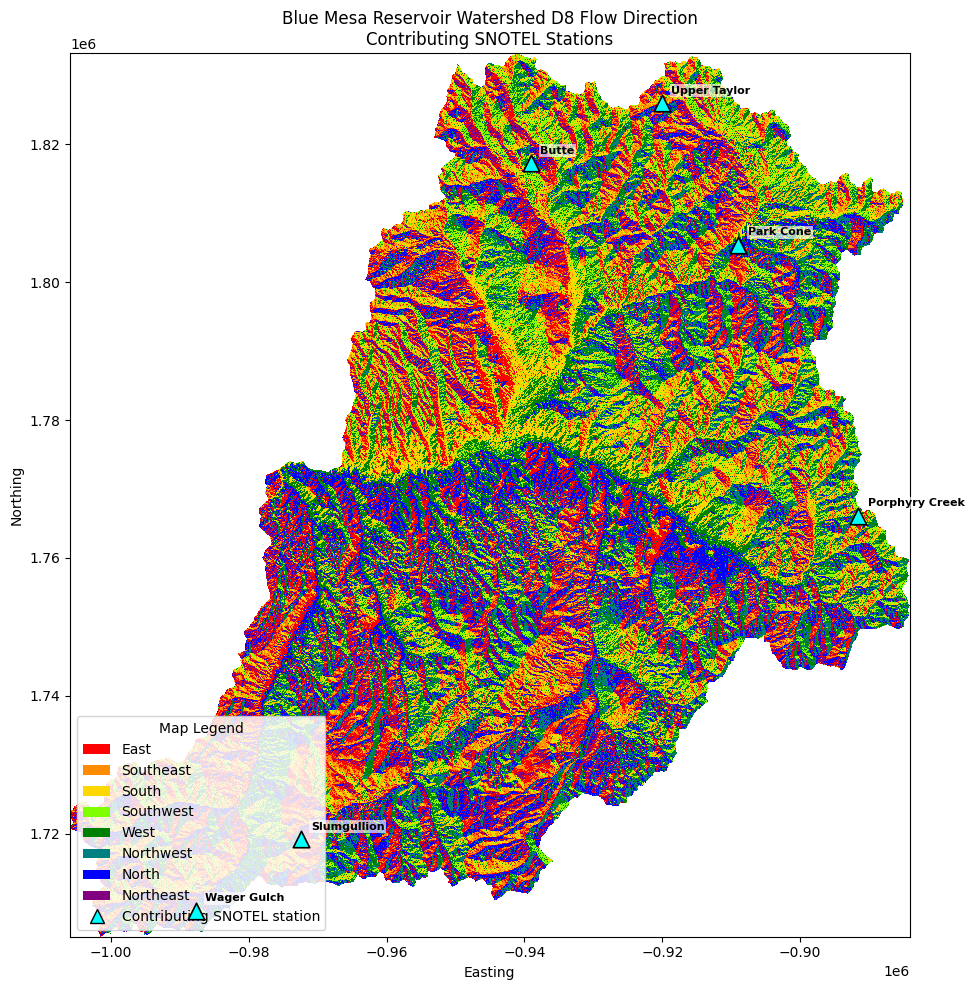

Pueblo Reservoir: 3 contributing stations
Saved: Pueblo_Reservoir_d8_contributing_snotel.png


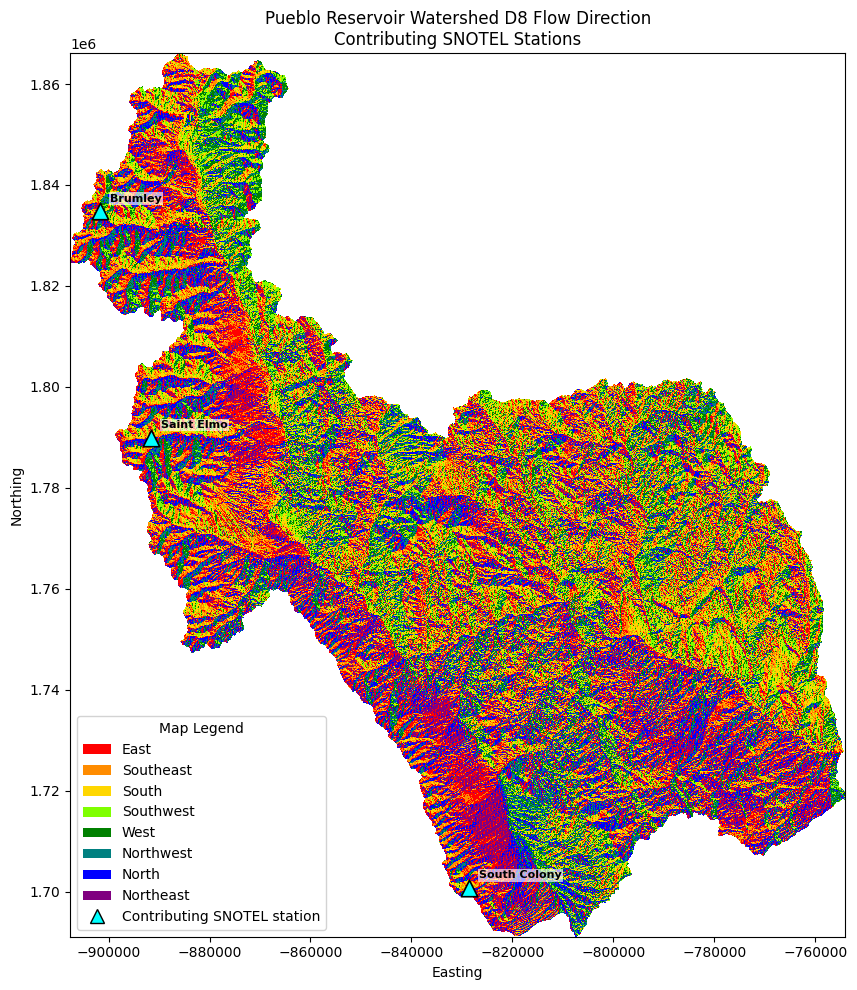

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import os

# D8 codes and direction names
d8_codes = [1, 2, 4, 8, 16, 32, 64, 128]

direction_names = [
    "East",
    "Southeast",
    "South",
    "Southwest",
    "West",
    "Northwest",
    "North",
    "Northeast"
]

colors = [
    "red",
    "darkorange",
    "gold",
    "chartreuse",
    "green",
    "teal",
    "blue",
    "purple"
]

# Correct class boundaries for D8 values
boundaries = [0.5, 1.5, 3, 6, 12, 24, 48, 96, 160]

cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

for _, result in d8_outputs.iterrows():

    reservoir_name = result["name"]
    flow_path = result["flow_direction"]

    with rasterio.open(flow_path) as src:

        flow_data = src.read(1).astype("float64")
        raster_crs = src.crs
        nodata = src.nodata

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

    # Hide invalid and NoData cells
    valid_d8_codes = [1, 2, 4, 8, 16, 32, 64, 128]

    flow_data[
        ~np.isin(flow_data, valid_d8_codes)
    ] = np.nan

    # Select only contributing stations for this reservoir
    stations_current = contributing_snotel_all[
        contributing_snotel_all["reservoir"]
        == reservoir_name
    ].copy()

    # Match stations to raster CRS
    if not stations_current.empty:
        stations_current = stations_current.to_crs(
            raster_crs
        )

    fig, ax = plt.subplots(figsize=(12, 10))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Plot D8 raster
    ax.imshow(
        flow_data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper",
        interpolation="nearest"
    )

    # Plot contributing SNOTEL stations
    if not stations_current.empty:

        stations_current.plot(
            ax=ax,
            marker="^",
            color="cyan",
            edgecolor="black",
            linewidth=1.2,
            markersize=140,
            zorder=10
        )

        # Station labels
        for _, station in stations_current.iterrows():

            ax.annotate(
                station["name"],
                xy=(
                    station.geometry.x,
                    station.geometry.y
                ),
                xytext=(7, 7),
                textcoords="offset points",
                fontsize=8,
                fontweight="bold",
                color="black",
                bbox={
                    "facecolor": "white",
                    "alpha": 0.65,
                    "edgecolor": "none",
                    "pad": 1
                },
                zorder=11
            )

    # D8 legend handles
    direction_handles = [
        Patch(
            facecolor=colors[i],
            label=direction_names[i]
        )
        for i in range(len(d8_codes))
    ]

    # SNOTEL legend symbol
    station_handle = Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markerfacecolor="cyan",
        markeredgecolor="black",
        markersize=10,
        label="Contributing SNOTEL station"
    )

    ax.legend(
        handles=direction_handles + [station_handle],
        title="Map Legend",
        loc="lower left",
        framealpha=0.85
    )

    ax.set_title(
        f"{reservoir_name} Watershed D8 Flow Direction\n"
        f"Contributing SNOTEL Stations"
    )

    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

    # Keep plot focused on the raster
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    plt.tight_layout()

    output_filename = (
        f"{reservoir_name.replace(' ', '_')}"
        "_d8_contributing_snotel.png"
    )

    plt.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        f"{reservoir_name}: "
        f"{len(stations_current)} contributing stations"
    )
    print("Saved:", output_filename)

    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from metloom.variables import SnotelVariables

# ---------------------------------------------------------
# 1. Date range
# ---------------------------------------------------------
start_date = "1980-01-01"
end_date = "2025-12-31"

snow_months = [11, 12, 1, 2, 3, 4]

# One row per reservoir/station combination
station_table = (
    contributing_snotel_all[
        ["reservoir", "station_id", "name", "elevation_ft"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Contributing station records:", len(station_table))
display(station_table)

Contributing station records: 13


,reservoir,station_id,name,elevation_ft
0,Navajo Reservoir,840:CO:SNTL,Upper San Juan,10140.0
1,Navajo Reservoir,843:CO:SNTL,Vallecito,10740.0
2,Navajo Reservoir,1160:CO:SNTL,Weminuche Creek,10730.0
3,Navajo Reservoir,874:CO:SNTL,Wolf Creek Summit,10930.0
4,Blue Mesa Reservoir,762:CO:SNTL,Slumgullion,11560.0
5,Blue Mesa Reservoir,701:CO:SNTL,Porphyry Creek,10790.0
6,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0
7,Blue Mesa Reservoir,1188:CO:SNTL,Wager Gulch,11110.0
8,Blue Mesa Reservoir,680:CO:SNTL,Park Cone,9600.0
9,Blue Mesa Reservoir,1141:CO:SNTL,Upper Taylor,10710.0


In [ ]:
# Match each station ID to its Metloom station object
station_object_lookup = {
    station.id: station
    for station in station_list
}

all_daily_swe = []
failed_downloads = []

for _, row in station_table.iterrows():

    reservoir_name = row["reservoir"]
    station_id = row["station_id"]
    station_name = row["name"]

    print(
        f"Downloading {station_name} "
        f"({station_id}) for {reservoir_name}"
    )

    station_object = station_object_lookup.get(station_id)

    if station_object is None:
        print("  Station object not found")
        failed_downloads.append({
            "reservoir": reservoir_name,
            "station_id": station_id,
            "station_name": station_name,
            "error": "Station object not found"
        })
        continue

    try:
        daily = station_object.get_daily_data(
            start_date=start_date,
            end_date=end_date,
            variables=[SnotelVariables.SWE]
        )

        if daily is None or len(daily) == 0:
            print("  No daily SWE returned")
            continue

        daily = daily.copy()

        # Flatten MultiIndex columns if Metloom returned them
        if isinstance(daily.columns, pd.MultiIndex):
            daily.columns = [
                "_".join(
                    str(part)
                    for part in column
                    if str(part) not in ["", "None"]
                )
                for column in daily.columns
            ]

        # Move the datetime index into a regular column
        daily = daily.reset_index()

        # Add identifying information
        daily["reservoir"] = reservoir_name
        daily["station_id"] = station_id
        daily["station_name"] = station_name
        daily["elevation_ft"] = row["elevation_ft"]

        all_daily_swe.append(daily)

        print("  Rows downloaded:", len(daily))

    except Exception as error:
        print("  Failed:", error)

        failed_downloads.append({
            "reservoir": reservoir_name,
            "station_id": station_id,
            "station_name": station_name,
            "error": str(error)
        })

  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range
  Failed: list index out of range


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from metloom.variables import SnotelVariables

start_date = datetime(1980, 1, 1)
end_date = datetime(2025, 12, 31)

snow_months = [11, 12, 1, 2, 3, 4]

station_table = (
    contributing_snotel_all[
        ["reservoir", "station_id", "name", "elevation_ft"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

station_object_lookup = {
    station.id: station
    for station in station_list
}

all_daily_swe = []
failed_downloads = []

for _, row in station_table.iterrows():

    station_id = row["station_id"]
    station_name = row["name"]
    reservoir_name = row["reservoir"]

    station_object = station_object_lookup.get(station_id)

    print(
        f"Downloading {station_name} "
        f"({station_id}) for {reservoir_name}"
    )

    if station_object is None:
        print("  Station object not found")
        continue

    try:
        daily = station_object.get_daily_data(
            start_date=start_date,
            end_date=end_date,
            variables=[SnotelVariables.SWE]
        )

        if daily is None or daily.empty:
            print("  No data returned")
            continue

        daily = daily.copy()

        if isinstance(daily.columns, pd.MultiIndex):
            daily.columns = [
                "_".join(
                    str(part)
                    for part in column
                    if str(part) not in ["", "None"]
                )
                for column in daily.columns
            ]

        daily = daily.reset_index()

        daily["reservoir"] = reservoir_name
        daily["station_id"] = station_id
        daily["station_name"] = station_name
        daily["elevation_ft"] = row["elevation_ft"]

        all_daily_swe.append(daily)

        print("  Downloaded rows:", len(daily))

    except Exception as error:
        print("  FAILED:", repr(error))

        failed_downloads.append({
            "reservoir": reservoir_name,
            "station_id": station_id,
            "station_name": station_name,
            "error": repr(error)
        })

  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')
  FAILED: IndexError('list index out of range')


In [ ]:
print("Successful downloads:", len(all_daily_swe))
print("Failed downloads:", len(failed_downloads))

if failed_downloads:
    display(pd.DataFrame(failed_downloads))

Successful downloads: 0
Failed downloads: 13


,reservoir,station_id,station_name,error
0,Navajo Reservoir,840:CO:SNTL,Upper San Juan,IndexError('list index out of range')
1,Navajo Reservoir,843:CO:SNTL,Vallecito,IndexError('list index out of range')
2,Navajo Reservoir,1160:CO:SNTL,Weminuche Creek,IndexError('list index out of range')
3,Navajo Reservoir,874:CO:SNTL,Wolf Creek Summit,IndexError('list index out of range')
4,Blue Mesa Reservoir,762:CO:SNTL,Slumgullion,IndexError('list index out of range')
5,Blue Mesa Reservoir,701:CO:SNTL,Porphyry Creek,IndexError('list index out of range')
6,Blue Mesa Reservoir,380:CO:SNTL,Butte,IndexError('list index out of range')
7,Blue Mesa Reservoir,1188:CO:SNTL,Wager Gulch,IndexError('list index out of range')
8,Blue Mesa Reservoir,680:CO:SNTL,Park Cone,IndexError('list index out of range')
9,Blue Mesa Reservoir,1141:CO:SNTL,Upper Taylor,IndexError('list index out of range')


In [ ]:
failed_df = pd.DataFrame(failed_downloads)

display(
    failed_df[
        [
            "reservoir",
            "station_name",
            "station_id",
            "error"
        ]
    ]
)

,reservoir,station_name,station_id,error
0,Navajo Reservoir,Upper San Juan,840:CO:SNTL,IndexError('list index out of range')
1,Navajo Reservoir,Vallecito,843:CO:SNTL,IndexError('list index out of range')
2,Navajo Reservoir,Weminuche Creek,1160:CO:SNTL,IndexError('list index out of range')
3,Navajo Reservoir,Wolf Creek Summit,874:CO:SNTL,IndexError('list index out of range')
4,Blue Mesa Reservoir,Slumgullion,762:CO:SNTL,IndexError('list index out of range')
5,Blue Mesa Reservoir,Porphyry Creek,701:CO:SNTL,IndexError('list index out of range')
6,Blue Mesa Reservoir,Butte,380:CO:SNTL,IndexError('list index out of range')
7,Blue Mesa Reservoir,Wager Gulch,1188:CO:SNTL,IndexError('list index out of range')
8,Blue Mesa Reservoir,Park Cone,680:CO:SNTL,IndexError('list index out of range')
9,Blue Mesa Reservoir,Upper Taylor,1141:CO:SNTL,IndexError('list index out of range')


In [ ]:
print(failed_downloads[0]["error"])

IndexError('list index out of range')


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from metloom.variables import SnotelVariables

# Contributing stations only
station_table = (
    contributing_snotel_all[
        ["reservoir", "station_id", "name", "elevation_ft"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Match IDs to the Metloom objects already retrieved
station_object_lookup = {
    station.id: station
    for station in station_list
}

all_daily_swe = []
failed_requests = []

for _, row in station_table.iterrows():

    reservoir = row["reservoir"]
    station_id = row["station_id"]
    station_name = row["name"]

    station = station_object_lookup.get(station_id)

    if station is None:
        print(f"Station object missing: {station_name}")
        continue

    print(f"\n{reservoir}: {station_name} ({station_id})")

    # Download one calendar year at a time
    for year in range(1980, 2026):

        start_date = datetime(year, 1, 1)
        end_date = datetime(year, 12, 31)

        try:
            annual = station.get_daily_data(
                start_date=start_date,
                end_date=end_date,
                variables=[SnotelVariables.SWE]
            )

            # No data usually means station was not operating that year
            if annual is None or annual.empty:
                continue

            annual = annual.copy().reset_index()

            # Flatten columns if needed
            if isinstance(annual.columns, pd.MultiIndex):
                annual.columns = [
                    "_".join(
                        str(part)
                        for part in column
                        if str(part) not in ["", "None"]
                    )
                    for column in annual.columns
                ]

            annual["reservoir"] = reservoir
            annual["station_id"] = station_id
            annual["station_name"] = station_name
            annual["elevation_ft"] = row["elevation_ft"]

            all_daily_swe.append(annual)

            print(f"  {year}: {len(annual)} rows")

        except IndexError:
            # NRCS returned an empty result for this station/year
            continue

        except Exception as error:
            failed_requests.append({
                "reservoir": reservoir,
                "station_id": station_id,
                "station_name": station_name,
                "year": year,
                "error": repr(error)
            })


Navajo Reservoir: Upper San Juan (840:CO:SNTL)

Navajo Reservoir: Vallecito (843:CO:SNTL)



Navajo Reservoir: Weminuche Creek (1160:CO:SNTL)


KeyboardInterrupt: 

In [ ]:
import requests
import pandas as pd
from io import StringIO

station_id = "624:CO:SNTL"   # Middle Creek

url = (
    "https://wcc.sc.egov.usda.gov/reportGenerator/"
    "view_csv/customSingleStationReport/daily/start_of_period/"
    f"{station_id}%7Cid=%22%22%7Cname/"
    "1980-01-01,2025-12-31/"
    "WTEQ::value"
)

response = requests.get(url, timeout=120)

print("Status:", response.status_code)
print(response.text[:500])

Status: 200
#------------------------------------------------- WARNING --------------------------------------------
# 
# The data you have obtained from this automated Natural Resources Conservation Service 
# database are subject to revision regardless of indicated Quality Assurance level. 
# Data are released on condition that neither the NRCS nor the United States Government 
# may be held liable for any damages resulting from its use. 
# 
# SNOTEL air temperature data contains a known bias. This bias is


In [ ]:
import requests
import pandas as pd
from io import StringIO

station_id = "624:CO:SNTL"   # Middle Creek

url = (
    "https://wcc.sc.egov.usda.gov/reportGenerator/"
    "view_csv/customSingleStationReport/daily/start_of_period/"
    f"{station_id}%7Cid=%22%22%7Cname/"
    "1980-01-01,2025-12-31/"
    "WTEQ::value"
)

response = requests.get(url, timeout=120)

print("Status:", response.status_code)
print(response.text[:500])

Status: 200
#------------------------------------------------- WARNING --------------------------------------------
# 
# The data you have obtained from this automated Natural Resources Conservation Service 
# database are subject to revision regardless of indicated Quality Assurance level. 
# Data are released on condition that neither the NRCS nor the United States Government 
# may be held liable for any damages resulting from its use. 
# 
# SNOTEL air temperature data contains a known bias. This bias is


In [ ]:
lines = [
    line
    for line in response.text.splitlines()
    if not line.startswith("#")
]

test_swe = pd.read_csv(
    StringIO("\n".join(lines))
)

display(test_swe.head())
print(test_swe.columns)

,Date,Snow Water Equivalent (in) Start of Day Values
0,1980-08-03,0.0
1,1980-08-04,0.0
2,1980-08-05,0.0
3,1980-08-06,0.0
4,1980-08-07,0.0


Index(['Date', 'Snow Water Equivalent (in) Start of Day Values'], dtype='object')


In [ ]:
import requests
import pandas as pd
import numpy as np
import time
from io import StringIO

station_table = (
    contributing_snotel_all[
        ["reservoir", "station_id", "name", "elevation_ft"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

all_daily_swe = []
failed_stations = []

for _, row in station_table.iterrows():

    station_id = row["station_id"]
    station_name = row["name"]
    reservoir = row["reservoir"]

    url = (
        "https://wcc.sc.egov.usda.gov/reportGenerator/"
        "view_csv/customSingleStationReport/daily/start_of_period/"
        f"{station_id}%7Cid=%22%22%7Cname/"
        "1980-01-01,2025-12-31/"
        "WTEQ::value"
    )

    print(f"Downloading {station_name} ({station_id})")

    try:
        response = requests.get(
            url,
            timeout=180
        )

        if response.status_code != 200:
            raise RuntimeError(
                f"HTTP {response.status_code}"
            )

        lines = [
            line
            for line in response.text.splitlines()
            if line.strip()
            and not line.startswith("#")
        ]

        if len(lines) < 2:
            raise ValueError("No data returned")

        data = pd.read_csv(
            StringIO("\n".join(lines))
        )

        data["reservoir"] = reservoir
        data["station_id"] = station_id
        data["station_name"] = station_name
        data["elevation_ft"] = row["elevation_ft"]

        all_daily_swe.append(data)

        print("  Rows:", len(data))

    except Exception as error:
        print("  Failed:", error)

        failed_stations.append({
            "reservoir": reservoir,
            "station_id": station_id,
            "station_name": station_name,
            "error": repr(error)
        })

    time.sleep(1)

  Rows: 16802
  Rows: 14373
  Rows: 5571
  Rows: 14378
  Rows: 16577
  Rows: 16802
  Rows: 16528
  Rows: 5216
  Rows: 16586
  Rows: 5936
  Rows: 6667
  Failed: HTTP 500
  Rows: 12511


In [ ]:
print("Successful stations:", len(all_daily_swe))
print("Failed stations:", len(failed_stations))

if failed_stations:
    display(pd.DataFrame(failed_stations))

Successful stations: 12
Failed stations: 1


,reservoir,station_id,station_name,error
0,Pueblo Reservoir,369:CO:SNTL,Brumley,RuntimeError('HTTP 500')


In [ ]:
import requests
import pandas as pd
import time
from io import StringIO

station_id = "369:CO:SNTL"
station_name = "Brumley"
reservoir = "Pueblo Reservoir"
elevation_ft = station_table.loc[
    station_table["station_id"] == station_id,
    "elevation_ft"
].iloc[0]

brumley_parts = []
brumley_failures = []

# Download five years at a time
for start_year in range(1980, 2026, 5):

    end_year = min(start_year + 4, 2025)

    start_date = f"{start_year}-01-01"
    end_date = f"{end_year}-12-31"

    url = (
        "https://wcc.sc.egov.usda.gov/reportGenerator/"
        "view_csv/customSingleStationReport/daily/start_of_period/"
        f"{station_id}%7Cid=%22%22%7Cname/"
        f"{start_date},{end_date}/"
        "WTEQ::value"
    )

    print(f"Downloading {start_year}-{end_year}")

    try:
        response = requests.get(url, timeout=180)

        if response.status_code != 200:
            raise RuntimeError(
                f"HTTP {response.status_code}"
            )

        lines = [
            line
            for line in response.text.splitlines()
            if line.strip()
            and not line.startswith("#")
        ]

        if len(lines) < 2:
            print("  No data")
            continue

        part = pd.read_csv(
            StringIO("\n".join(lines))
        )

        part["reservoir"] = reservoir
        part["station_id"] = station_id
        part["station_name"] = station_name
        part["elevation_ft"] = elevation_ft

        brumley_parts.append(part)

        print("  Rows:", len(part))

    except Exception as error:
        print("  Failed:", error)

        brumley_failures.append({
            "start_year": start_year,
            "end_year": end_year,
            "error": repr(error)
        })

    time.sleep(1)

  Rows: 1553
  Rows: 1826
  Rows: 1826
  Rows: 1826
  Rows: 1827
  Rows: 1826
  Rows: 1826
  Rows: 1826
  Rows: 1827
  Rows: 365


In [ ]:
print("Successful Brumley chunks:", len(brumley_parts))
print("Failed Brumley chunks:", len(brumley_failures))

if brumley_failures:
    display(pd.DataFrame(brumley_failures))

Successful Brumley chunks: 10
Failed Brumley chunks: 0


In [ ]:
if brumley_parts:

    brumley_daily = pd.concat(
        brumley_parts,
        ignore_index=True
    )

    # Remove any duplicate dates caused by overlapping responses
    date_col = next(
        column
        for column in brumley_daily.columns
        if "date" in column.lower()
    )

    brumley_daily = brumley_daily.drop_duplicates(
        subset=[date_col, "station_id", "reservoir"]
    )

    # Add to your 12 successful station datasets
    all_daily_swe.append(brumley_daily)

    print(
        "Brumley rows added:",
        len(brumley_daily)
    )

Brumley rows added: 16528


In [ ]:
daily_swe = pd.concat(
    all_daily_swe,
    ignore_index=True
)

print("Stations in combined data:")
print(
    daily_swe[
        ["reservoir", "station_id", "station_name"]
    ]
    .drop_duplicates()
    .sort_values(["reservoir", "station_name"])
)

print(
    "Total unique stations:",
    daily_swe["station_id"].nunique()
)

Stations in combined data:
                  reservoir    station_id       station_name
84503   Blue Mesa Reservoir   380:CO:SNTL              Butte
106247  Blue Mesa Reservoir   680:CO:SNTL          Park Cone
67701   Blue Mesa Reservoir   701:CO:SNTL     Porphyry Creek
51124   Blue Mesa Reservoir   762:CO:SNTL        Slumgullion
122833  Blue Mesa Reservoir  1141:CO:SNTL       Upper Taylor
101031  Blue Mesa Reservoir  1188:CO:SNTL        Wager Gulch
0          Navajo Reservoir   840:CO:SNTL     Upper San Juan
16802      Navajo Reservoir   843:CO:SNTL          Vallecito
31175      Navajo Reservoir  1160:CO:SNTL    Weminuche Creek
36746      Navajo Reservoir   874:CO:SNTL  Wolf Creek Summit
147947     Pueblo Reservoir   369:CO:SNTL            Brumley
128769     Pueblo Reservoir  1100:CO:SNTL         Saint Elmo
135436     Pueblo Reservoir   773:CO:SNTL       South Colony
Total unique stations: 13


In [ ]:
daily_swe = pd.concat(
    all_daily_swe,
    ignore_index=True
)

print("Stations in combined data:")
print(
    daily_swe[
        ["reservoir", "station_id", "station_name"]
    ]
    .drop_duplicates()
    .sort_values(["reservoir", "station_name"])
)

print(
    "Total unique stations:",
    daily_swe["station_id"].nunique()
)

Stations in combined data:
                  reservoir    station_id       station_name
84503   Blue Mesa Reservoir   380:CO:SNTL              Butte
106247  Blue Mesa Reservoir   680:CO:SNTL          Park Cone
67701   Blue Mesa Reservoir   701:CO:SNTL     Porphyry Creek
51124   Blue Mesa Reservoir   762:CO:SNTL        Slumgullion
122833  Blue Mesa Reservoir  1141:CO:SNTL       Upper Taylor
101031  Blue Mesa Reservoir  1188:CO:SNTL        Wager Gulch
0          Navajo Reservoir   840:CO:SNTL     Upper San Juan
16802      Navajo Reservoir   843:CO:SNTL          Vallecito
31175      Navajo Reservoir  1160:CO:SNTL    Weminuche Creek
36746      Navajo Reservoir   874:CO:SNTL  Wolf Creek Summit
147947     Pueblo Reservoir   369:CO:SNTL            Brumley
128769     Pueblo Reservoir  1100:CO:SNTL         Saint Elmo
135436     Pueblo Reservoir   773:CO:SNTL       South Colony
Total unique stations: 13


In [ ]:
date_column = next(
    col for col in daily_swe.columns
    if "date" in col.lower()
)

swe_column = next(
    col for col in daily_swe.columns
    if (
        "snow water equivalent" in col.lower()
        or "wteq" in col.lower()
    )
)

print("Date column:", date_column)
print("SWE column:", swe_column)

Date column: Date
SWE column: Snow Water Equivalent (in) Start of Day Values


In [ ]:
daily_swe["date"] = pd.to_datetime(
    daily_swe[date_column],
    errors="coerce"
)

daily_swe["swe_inches"] = pd.to_numeric(
    daily_swe[swe_column],
    errors="coerce"
)

daily_swe = daily_swe.dropna(
    subset=["date", "swe_inches"]
).copy()

daily_swe = daily_swe[
    daily_swe["date"].between(
        "1980-01-01",
        "2025-12-31"
    )
].copy()

daily_swe_nov_apr = daily_swe[
    daily_swe["date"].dt.month.isin(
        [11, 12, 1, 2, 3, 4]
    )
].copy()

daily_swe_nov_apr["calendar_year"] = (
    daily_swe_nov_apr["date"].dt.year
)

daily_swe_nov_apr["month"] = (
    daily_swe_nov_apr["date"].dt.month
)

daily_swe_nov_apr["month_name"] = (
    daily_swe_nov_apr["date"].dt.strftime("%b")
)

# Nov and Dec belong to the following snow season
daily_swe_nov_apr["water_year"] = np.where(
    daily_swe_nov_apr["month"].isin([11, 12]),
    daily_swe_nov_apr["calendar_year"] + 1,
    daily_swe_nov_apr["calendar_year"]
)

In [ ]:
monthly_station_swe = (
    daily_swe_nov_apr
    .groupby(
        [
            "reservoir",
            "station_id",
            "station_name",
            "elevation_ft",
            "water_year",
            "calendar_year",
            "month",
            "month_name"
        ],
        as_index=False
    )
    .agg(
        monthly_mean_swe_inches=(
            "swe_inches",
            "mean"
        ),
        daily_observations=(
            "swe_inches",
            "count"
        )
    )
)

month_order = {
    11: 1,
    12: 2,
    1: 3,
    2: 4,
    3: 5,
    4: 6
}

monthly_station_swe["snow_month_order"] = (
    monthly_station_swe["month"].map(month_order)
)

monthly_station_swe = monthly_station_swe.sort_values(
    [
        "reservoir",
        "station_name",
        "water_year",
        "snow_month_order"
    ]
).reset_index(drop=True)

display(monthly_station_swe.head(20))

,reservoir,station_id,station_name,elevation_ft,water_year,calendar_year,month,month_name,monthly_mean_swe_inches,daily_observations,snow_month_order
0,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1981,1980,11,Nov,1.473333,30,1
1,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1981,1980,12,Dec,2.609677,31,2
2,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1981,1981,1,Jan,3.203226,31,3
3,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1981,1981,2,Feb,4.382143,28,4
4,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1981,1981,3,Mar,6.235484,31,5
5,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1981,1981,4,Apr,6.120000,30,6
6,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1982,1981,11,Nov,1.270000,30,1
7,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1982,1981,12,Dec,3.519355,31,2
8,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1982,1982,1,Jan,10.296774,31,3
9,Blue Mesa Reservoir,380:CO:SNTL,Butte,10190.0,1982,1982,2,Feb,12.617857,28,4


In [ ]:
monthly_reservoir_swe = (
    monthly_station_swe
    .groupby(
        [
            "reservoir",
            "water_year",
            "calendar_year",
            "month",
            "month_name",
            "snow_month_order"
        ],
        as_index=False
    )
    .agg(
        reservoir_monthly_mean_swe_inches=(
            "monthly_mean_swe_inches",
            "mean"
        ),
        stations_reporting=(
            "station_id",
            "nunique"
        )
    )
    .sort_values(
        [
            "reservoir",
            "water_year",
            "snow_month_order"
        ]
    )
    .reset_index(drop=True)
)

display(monthly_reservoir_swe.head(20))

,reservoir,water_year,calendar_year,month,month_name,snow_month_order,reservoir_monthly_mean_swe_inches,stations_reporting
0,Blue Mesa Reservoir,1980,1980,1,Jan,3,6.816129,1
1,Blue Mesa Reservoir,1980,1980,2,Feb,4,11.372414,1
2,Blue Mesa Reservoir,1980,1980,3,Mar,5,16.180645,1
3,Blue Mesa Reservoir,1980,1980,4,Apr,6,19.983333,1
4,Blue Mesa Reservoir,1981,1980,11,Nov,1,0.955833,4
5,Blue Mesa Reservoir,1981,1980,12,Dec,2,2.315323,4
6,Blue Mesa Reservoir,1981,1981,1,Jan,3,3.006452,4
7,Blue Mesa Reservoir,1981,1981,2,Feb,4,4.341964,4
8,Blue Mesa Reservoir,1981,1981,3,Mar,5,6.667742,4
9,Blue Mesa Reservoir,1981,1981,4,Apr,6,6.246667,4


In [ ]:
monthly_station_swe.to_csv(
    "/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv",
    index=False
)

monthly_reservoir_swe.to_csv(
    "/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv",
    index=False
)

print("Monthly station and reservoir files saved.")

Monthly station and reservoir files saved.


In [ ]:
# Save the daily November-April data
daily_swe_nov_apr.to_csv(
    "/content/snotel_daily_swe_nov_apr_1980_2025.csv",
    index=False
)

# Save station-level monthly means
monthly_station_swe.to_csv(
    "/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv",
    index=False
)

# Save reservoir-level monthly means
monthly_reservoir_swe.to_csv(
    "/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv",
    index=False
)

print("Saved to Colab:")
print("/content/snotel_daily_swe_nov_apr_1980_2025.csv")
print("/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv")
print("/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv")

Saved to Colab:
/content/snotel_daily_swe_nov_apr_1980_2025.csv
/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv
/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv


In [ ]:
import os

files = [
    "/content/snotel_daily_swe_nov_apr_1980_2025.csv",
    "/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv",
    "/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv"
]

for file in files:
    print(file, os.path.exists(file))

/content/snotel_daily_swe_nov_apr_1980_2025.csv True
/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv True
/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv True


In [ ]:
from google.colab import files

files.download(
    "/content/snotel_station_monthly_mean_nov_apr_1980_2025.csv"
)

files.download(
    "/content/snotel_reservoir_monthly_mean_nov_apr_1980_2025.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>